# 2.2 Regionalstatistik Kreise-Level Crop Yields

**Goal:** Fetch NUTS-3 (Landkreis) level crop yields from the Destatis Genesis / Regionalstatistik REST API and evaluate coverage for Brandenburg + Saxony (Lusatia focus area).

- **Data source:** Regionalstatistik.de - same Genesis REST API as destatis.de but with Kreise-level data
- **Table:** `41241-0002` - Erntemengen & Erträge nach Fruchtarten (Kreisergebnisse)
- **Auth:** POST-only, token-as-username, password empty, form-encoded body (GET disabled since July 2025)
- **Licence:** Datenlizenz Deutschland - Namensnennung - Version 2.0

**Decision criteria:** If we get ≥10 years of yield data for ≥80% of BB/SN Landkreise => **ingest**.

In [1]:
import io
import json
import os
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import requests
from dotenv import load_dotenv

# Load .env from project root
load_dotenv(Path("../.env"))

CACHE_DIR = Path("_cache")
DB_PATH = CACHE_DIR / "agri_weather_yield.duckdb"

API endpoints

In [2]:
GENESIS_BASE = "https://www-genesis.destatis.de/genesisWS/rest/2020"
REGIO_BASE = "https://www.regionalstatistik.de/genesisws/rest/2020"
POST_HEADERS = {"Content-Type": "application/x-www-form-urlencoded"}

Genesis auth (destatis.de) — token-as-username

In [3]:
GENESIS_TOKEN = os.environ.get("DESTATIS_API_TOKEN", "")
assert GENESIS_TOKEN, "Set DESTATIS_API_TOKEN in .env"
GENESIS_AUTH = {"username": GENESIS_TOKEN, "password": ""}

Regionalstatistik auth (separate registration)

In [4]:
REGIO_USER = os.environ.get("REGIONALSTATISTIK_GENESIS_USERNAME", "")
REGIO_PASS = os.environ.get("REGIONALSTATISTIK_GENESIS_PASSWORD", "")
assert REGIO_USER, "Set REGIONALSTATISTIK_GENESIS_USERNAME in .env"
REGIO_AUTH = {"username": REGIO_USER, "password": REGIO_PASS}

DuckDB connection (reuse existing mini DWH)

In [5]:
con = duckdb.connect(str(DB_PATH))
con.execute("install spatial; load spatial;")

In [6]:
print(f"""
Genesis token:  {GENESIS_TOKEN[:4]:*<16}
Regio user:     {REGIO_USER[:3]:*<8}
DuckDB path:    {DB_PATH}
""")


Genesis token:  ba3c************
Regio user:     RE0*****
DuckDB path:    _cache/agri_weather_yield.duckdb



## 1. Login check

Test connectivity against both Genesis (destatis.de) and Regionalstatistik APIs.

In [7]:
for name, base_url, auth in [
    ("Genesis", GENESIS_BASE, GENESIS_AUTH),
    ("Regionalstatistik", REGIO_BASE, REGIO_AUTH),
]:
    resp = requests.post(
        f"{base_url}/helloworld/logincheck",
        headers=POST_HEADERS,
        data={**auth, "language": "en"},
        timeout=15,
    )
    resp.raise_for_status()
    msg = resp.json().get("Status", resp.text[:200])
    ok = "successfully" in msg.lower()
    print(f"{'OK' if ok else 'ERROR'} {name}: {msg[:200]}")
    assert ok, f"{base_url} failed"

OK Genesis: You have been logged in and out successfully! If there were more than 3 parallel requests, those that had been running for more than 15 minutes were terminated
OK Regionalstatistik: You have been logged in and out successfully! If there were more than 10 parallel requests, those that had been running for more than 15 minutes were terminated


So we may also conclude that:

1. Federal-level Genesis has a quota of 3 parallel requests with a 15 minute window.
2. Regional-level Genesis has a quota of 10 parallel requests with a 15 minute window.

Let's now identify the data set codes we're interested in. By inspection of the website, we know that we need to look closer at subject "41" (Bodennutzung und pflanzliche Erzeugung):

In [8]:
GENESIS_HEADERS = {**POST_HEADERS, "username": GENESIS_TOKEN, "password": ""}

resp = requests.post(
    f"{GENESIS_BASE}/catalogue/statistics",
    headers=GENESIS_HEADERS,
    data={
        "language": "de",
        "searchcriterion": "Code",
        "selection": "41*",
        "pagelength": "200",
    },
    timeout=30,
)
resp.raise_for_status()
result = resp.json()

In [9]:
# For legibility, we'll just craete data frames from JSON response payloads (simple one-liners
# instead of printing out arrays of objects). Performance ok for this purpose.
stats_df = pd.read_json(io.StringIO(json.dumps(result["List"])))  # assuming List properety exists in response
stats_df

,Code,Content,Cubes,Information
0,41122,Repräsentative Agrarstrukturerhebung (ASE b. 2...,40,true
1,41141,Landwirtschaftszählung: Haupterhebung,176,true
2,41145,Landwirtschaftszählung: Gartenbau,22,true
3,41161,Strukturerhebung der Forstbetriebe,9,true
4,41213,Allgemeine Zierpflanzenerhebung,25,true
5,41214,Erhebung über Speisepilze,2,true
6,41215,Gemüseerhebung,16,true
7,41221,Baumschulerhebung,8,true
8,41231,Baumobstanbauerhebung,12,true
9,41232,Erhebung über Strauchbeeren,14,true


Inspecting the code descriptions, we're interested in:

- **41241** - Ernte-u.Betriebsbericht: Feldfrüchte und Grünland -> field crops, our goal here (crop yields) -> this is enough for a first EDA
- 41221 - Baumschulerhebung -> this is interesting, we'll investigate it separately, there is a likely correlation between certain arboreal families and sandy soils
- 41243 - tree fruits like appes and pears, likely low signal for sandy soils
- 41141 - will need to look closer

Unrelated:

- 4121* - vegetables and mushrooms
- 41244 and 4125* are about grapes and wineries -> not really relevant (mountanous areas)
- 413* are about livestock (cattle, birds, fish)

So now we can focus on this code: 41241, which serves as a prefix in the Genesis taxonomy.

## 2. Discover/peek at yield tables

Since our goal is to explore data on crop yields, we'll search the Regionalstatistik catalog for table `41241` (Erntemengen & Erträge) and similar agriculture tables available at Kreise level.

### Regionalstatistik catalog: yield tables at Kreise level (NUTS-3)

Note:

- Regionalstatistik needs auth in HEADERS (not body), see their OpenAPI/Swagger spec.
- `logincheck` works with request body, but all other endpoints require headers.

In [10]:
REGIO_HEADERS = {**POST_HEADERS, "username": REGIO_USER, "password": REGIO_PASS}

resp = requests.post(
    f"{REGIO_BASE}/catalogue/tables",
    headers=REGIO_HEADERS,
    data={"language": "de", "searchcriterion": "Code", "selection": "41241*", "pagelength": "50"},
    timeout=30,
)
resp.raise_for_status()  # If your password changes, you'll need to reload .env (just rerun the first code cell)
result = resp.json()
tables = result.get("List", [])

result

{'Ident': {'Service': 'catalogue', 'Method': 'tables'},
 'Status': {'Code': 0, 'Content': 'erfolgreich', 'Type': 'Information'},
 'Parameter': {'username': '********************',
  'password': '********************',
  'selection': '41241*',
  'area': 'Öffentlich',
  'searchcriterion': 'Code',
  'sortcriterion': 'Code',
  'pagelength': '50',
  'language': 'de'},
 'List': [{'Code': '41241-01-03-4',
   'Content': 'Erträge ausgewählter landwirtschaftlicher Feldfrüchte -\nJahressumme - regionale Tiefe: Kreise und krfr. Städte',
   'Time': '1999 - 2025'},
  {'Code': '41241-01-03-4-B',
   'Content': 'Erträge ausgewählter landwirtschaftlicher Feldfrüchte -\nJahressumme - regionale Ebenen',
   'Time': '1999 - 2025'}],
 'Copyright': '© Statistische Ämter des Bundes und der Länder, Deutschland, 2026.\nDieses Werk ist lizenziert unter der Datenlizenz Deutschland\n- Namensnennung - Version 2.0.'}

-> Regionalstatistik: just two tables matching `41241*` prefix:

In [11]:
pd.read_json(io.StringIO(json.dumps(result["List"])))

,Code,Content,Time
0,41241-01-03-4,Erträge ausgewählter landwirtschaftlicher Feld...,1999 - 2025
1,41241-01-03-4-B,Erträge ausgewählter landwirtschaftlicher Feld...,1999 - 2025


### Federal Genesis catalog: yield tables at Bundesland level (NUTS-1)

In [12]:
GENESIS_HEADERS = {**POST_HEADERS, "username": GENESIS_TOKEN, "password": ""}

resp = requests.post(
    f"{GENESIS_BASE}/catalogue/tables",
    headers=GENESIS_HEADERS,
    data={"language": "de", "searchcriterion": "Code", "selection": "41241*", "pagelength": "50"},
    timeout=30,
)
resp.raise_for_status()
result = resp.json()
tables = result.get("List", [])
result

{'Ident': {'Service': 'catalogue', 'Method': 'tables'},
 'Status': {'Code': 0, 'Content': 'erfolgreich', 'Type': 'Information'},
 'Parameter': {'username': '********************',
  'password': '********************',
  'selection': '41241*',
  'area': 'Öffentlich',
  'searchcriterion': 'Code',
  'sortcriterion': 'Code',
  'pagelength': '50',
  'language': 'de'},
 'List': [{'Code': '41241-0001',
   'Content': 'Anbaufläche (Feldfrüchte und Grünland): Deutschland, Jahre (bis 2009), Fruchtarten',
   'Time': '1950 - 2009'},
  {'Code': '41241-0002',
   'Content': 'Erntemenge (Feldfrüchte und Grünland): Deutschland, Jahre (bis 2009), Fruchtarten',
   'Time': '1950 - 2009'},
  {'Code': '41241-0003',
   'Content': 'Ertrag je Hektar (Feldfrüchte und Grünland): Deutschland,\nJahre (bis 2009), Fruchtarten',
   'Time': '1950 - 2009'},
  {'Code': '41241-0004',
   'Content': 'Landwirtschaftlich genutzte Fläche (Feldfrüchte und\nGrünland): Deutschland, Jahre (bis 2009), Kulturarten',
   'Time': '1950

-> Federal Genesis: eight tables matching `41241*` prefix:

In [13]:
pd.read_json(io.StringIO(json.dumps(result["List"])))

,Code,Content,Time
0,41241-0001,Anbaufläche (Feldfrüchte und Grünland): Deutsc...,1950 - 2009
1,41241-0002,Erntemenge (Feldfrüchte und Grünland): Deutsch...,1950 - 2009
2,41241-0003,Ertrag je Hektar (Feldfrüchte und Grünland): D...,1950 - 2009
3,41241-0004,Landwirtschaftlich genutzte Fläche (Feldfrücht...,1950 - 2009
4,41241-0005,"Anbaufläche, Erntemenge, Ertrag je Hektar (Fel...",2010 - 2025
5,41241-0006,"Erntemenge von Raufutter: Deutschland, Jahre, ...",2010 - 2025
6,41241-0010,"Anbaufläche, Erntemenge, Ertrag je Hektar (Fel...",2010 - 2025
7,41241-0011,"Erntemenge von Raufutter: Bundesländer, Jahre,...",2010 - 2025


## 3. Download and ingest Bundesland level yield data

First we're tackling the federal level data -> NUTS-1 mapping. Fetch tables

1. `41241-0003` from Federal Genesis in flat CSV format. This contains yields in dt/ha for major crops at national level (-> NUTS-0), and
2. `41241-0010` from Federal Genesis in flat CSV format. This contains yields in dt/ha for major crops at Bundesland level (-> NUTS-1),


### Download yields from federal Genesis (Bundesländer level)

First, a downloader utility function

In [14]:
def handle_genesis_response(resp: requests.Response, cache_csv: Path) -> None:
    import zipfile

    ct = resp.headers.get("content-type", "")
    print(f"HTTP {resp.status_code} | Content-Type: {ct} | Size: {len(resp.content) / 1024:.0f} KB")

    # Handle different response formats
    if "zip" in ct.lower() or resp.content[:2] == b"PK":
        with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
            names = zf.namelist()
            print(f"  zipped: {names}")
            if csv_name := [n for n in names if n.endswith(".csv")]:
                csv_text = zf.read(csv_name[0]).decode("utf-8-sig")
                cache_csv.write_text(csv_text, encoding="utf-8")
                print(f"  Extracted & cached: {cache_csv} ({len(csv_text) / 1024:.0f} KB)")
            else:
                print("  No CSV found in zip")
    elif "json" in ct.lower():
        if (data := resp.json()) and (csv_content := data.get("Object", "")) and ";" in str(csv_content)[:200]:
            cache_csv.write_text(csv_content, encoding="utf-8")
            print(f"  Cached JSON→CSV: {cache_csv} ({len(csv_content) / 1024:.0f} KB)")
        else:
            print(f"  Status: {data.get('Status', data)}")
    elif ";" in resp.text[:500]:
        cache_csv.write_text(resp.text, encoding="utf-8")
        print(f"  Cached raw CSV: {cache_csv} ({len(resp.text) / 1024:.0f} KB)")
    else:
        print(f"  Unknown format. Preview: {resp.text[:200]}")

In [15]:
def download_genesis_tables(table_code: str) -> None:
    cache_csv = CACHE_DIR / f"genesis_{table_code}.csv"
    if cache_csv.exists():
        return

    resp = requests.post(
        f"{GENESIS_BASE}/data/tablefile",
        headers=GENESIS_HEADERS,
        data={
            "name": table_code,
            "area": "all",
            "compress": "false",
            "format": "ffcsv",  # flat CSV with Geruropean semicolon delimiter and comma as decimal sep
            "language": "de",
            "startyear": "1999",
            "endyear": "2025",
        },
        timeout=120,
    )
    resp.raise_for_status()
    handle_genesis_response(resp, cache_csv)

In [16]:
for table_code, _description in [
    ("41241-0003", "National yields (Deutschland)"),
    ("41241-0010", "Bundesländer yields"),
]:
    download_genesis_tables(table_code)

In [17]:
bl_03_df = pd.read_csv(CACHE_DIR / "genesis_41241-0003.csv", sep=";", decimal=",", dtype={"statistics_code": str})
bl_03_df.describe()

,time
count,418.000000
mean,2004.000000
std,3.166067
min,1999.000000
25%,2001.000000
50%,2004.000000
75%,2007.000000
max,2009.000000


The national yields data set ranges from 1999 to 2009, which won't help us much.

In [18]:
bl_03_df.head(3)

,statistics_code,statistics_label,time_code,time_label,time,1_variable_code,1_variable_label,1_variable_attribute_code,1_variable_attribute_label,2_variable_code,2_variable_label,2_variable_attribute_code,2_variable_attribute_label,value,value_unit,value_variable_code,value_variable_label
0,41241,Ernte-u.Betriebsbericht: Feldfrüchte und Grünland,JAHR,Jahr,2000,DINSG,Deutschland insgesamt,DG,Deutschland,FRUA03,Fruchtarten,FRUART0513,Körnersonnenblumen,"24,8",dt/ha,ERT001,Ertrag je Hektar
1,41241,Ernte-u.Betriebsbericht: Feldfrüchte und Grünland,JAHR,Jahr,2000,DINSG,Deutschland insgesamt,DG,Deutschland,FRUA03,Fruchtarten,FRUART01212,Sommergerste,"46,3",dt/ha,ERT001,Ertrag je Hektar
2,41241,Ernte-u.Betriebsbericht: Feldfrüchte und Grünland,JAHR,Jahr,1999,DINSG,Deutschland insgesamt,DG,Deutschland,FRUA03,Fruchtarten,FRUART012,Futter- und Industriegetreide,"59,2",dt/ha,ERT001,Ertrag je Hektar


### Parse the Bundesländer ffcsv (flat CSV)

The ffcsv (flat CSV) format is semicolon-separated with German number formatting. Column names encode the table dimensions.



In [19]:
bl_10_df = pd.read_csv(
    CACHE_DIR / "genesis_41241-0010.csv",
    sep=";",
    decimal=",",
    dtype={"statistics_code": str, "1_variable_attribute_code": str},
)
bl_10_df.head(3)

,statistics_code,statistics_label,time_code,time_label,time,1_variable_code,1_variable_label,1_variable_attribute_code,1_variable_attribute_label,2_variable_code,2_variable_label,2_variable_attribute_code,2_variable_attribute_label,value,value_unit,value_variable_code,value_variable_label
0,41241,Ernte-u.Betriebsbericht: Feldfrüchte und Grünland,JAHR,Jahr,2013,DLAND,Bundesländer,11,Berlin,FRUA04,Fruchtarten,FRUART05112,"Sommerraps, Winter- und Sommerrübsen",-,ha,FLC016,Anbaufläche
1,41241,Ernte-u.Betriebsbericht: Feldfrüchte und Grünland,JAHR,Jahr,2013,DLAND,Bundesländer,11,Berlin,FRUA04,Fruchtarten,FRUART05112,"Sommerraps, Winter- und Sommerrübsen",-,dt/ha,ERT001,Ertrag je Hektar
2,41241,Ernte-u.Betriebsbericht: Feldfrüchte und Grünland,JAHR,Jahr,2013,DLAND,Bundesländer,11,Berlin,FRUA04,Fruchtarten,FRUART05112,"Sommerraps, Winter- und Sommerrübsen",-,t,ERN001,Erntemenge


#### Identify structure

Table 41241-0010 uses a denormalized/flat format where each row is one measurement (area, yield, or harvest) for one state × crop × year combination.

Unique value types (value_variable_code):

In [20]:
bl_10_df.groupby(["value_variable_code", "value_variable_label", "value_unit"]).value_counts()

value_variable_code  value_variable_label  value_unit  statistics_code  statistics_label                                   time_code  time_label  time  1_variable_code  1_variable_label  1_variable_attribute_code  1_variable_attribute_label  2_variable_code  2_variable_label  2_variable_attribute_code  2_variable_attribute_label                        value  
ERN001               Erntemenge            t           41241            Ernte-u.Betriebsbericht: Feldfrüchte und Grünland  JAHR       Jahr        2013  DLAND            Bundesländer      11                         Berlin                      FRUA04           Fruchtarten       FRUART05112                Sommerraps, Winter- und Sommerrübsen              -          1
                                                                                                                                                  2025  DLAND            Bundesländer      14                         Sachsen                     FRUA04           Fruchtarten 

In [21]:
bl_10_df.groupby(["value_variable_code", "value_variable_label", "value_unit"]).size().reset_index(name="n")

,value_variable_code,value_variable_label,value_unit,n
0,ERN001,Erntemenge,t,7936
1,ERT001,Ertrag je Hektar,dt/ha,7936
2,FLC016,Anbaufläche,ha,7936


Unique Bundesländer:

In [22]:
bl_10_df["1_variable_attribute_code"].nunique()

16

Unique years:

In [23]:
print(sorted(bl_10_df["time"].unique()))

[np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


Unique crops:

In [24]:
bl_10_df["2_variable_attribute_code"].nunique()

31

Crop codes:

In [ ]:
bl_10_df[["2_variable_attribute_code", "2_variable_attribute_label"]].drop_duplicates().sort_values("2_variable_attribute_code")

,2_variable_attribute_code,2_variable_attribute_label
9,FRUART0111,Weizen
459,FRUART01111DE,Winterweizen (einschließlich Dinkel und Einkorn)
39,FRUART01112OH,Sommerweizen (ohne Hartweizen)
54,FRUART01113,Hartweizen (Durum)
48,FRUART01121,Roggen und Wintermenggetreide
90,FRUART0121,Gerste
27,FRUART01211,Wintergerste
18,FRUART01212,Sommergerste
21,FRUART0122,Hafer
99,FRUART0123,Sommermenggetreide


#### Clean: extract yields (dt/ha) for key crops

Filter to yield rows only (ERT001 = Ertrag je Hektar):

In [26]:
yields_df = bl_10_df[bl_10_df["value_variable_code"] == "ERT001"].copy()
yields_df

,statistics_code,statistics_label,time_code,time_label,time,1_variable_code,1_variable_label,1_variable_attribute_code,1_variable_attribute_label,2_variable_code,2_variable_label,2_variable_attribute_code,2_variable_attribute_label,value,value_unit,value_variable_code,value_variable_label
1,41241,Ernte-u.Betriebsbericht: Feldfrüchte und Grünland,JAHR,Jahr,2013,DLAND,Bundesländer,11,Berlin,FRUA04,Fruchtarten,FRUART05112,"Sommerraps, Winter- und Sommerrübsen",-,dt/ha,ERT001,Ertrag je Hektar
4,41241,Ernte-u.Betriebsbericht: Feldfrüchte und Grünland,JAHR,Jahr,2025,DLAND,Bundesländer,14,Sachsen,FRUA04,Fruchtarten,FRUART065,Raufutter,"65,6",dt/ha,ERT001,Ertrag je Hektar
7,41241,Ernte-u.Betriebsbericht: Feldfrüchte und Grünland,JAHR,Jahr,2019,DLAND,Bundesländer,07,Rheinland-Pfalz,FRUA04,Fruchtarten,FRUART0511,Raps und Rübsen,"33,7",dt/ha,ERT001,Ertrag je Hektar
10,41241,Ernte-u.Betriebsbericht: Feldfrüchte und Grünland,JAHR,Jahr,2025,DLAND,Bundesländer,03,Niedersachsen,FRUA04,Fruchtarten,FRUART0111,Weizen,"83,0",dt/ha,ERT001,Ertrag je Hektar
13,41241,Ernte-u.Betriebsbericht: Feldfrüchte und Grünland,JAHR,Jahr,2025,DLAND,Bundesländer,02,Hamburg,FRUA04,Fruchtarten,FRUART025,Sojabohnen,/,dt/ha,ERT001,Ertrag je Hektar
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23794,41241,Ernte-u.Betriebsbericht: Feldfrüchte und Grünland,JAHR,Jahr,2018,DLAND,Bundesländer,01,Schleswig-Holstein,FRUA04,Fruchtarten,FRUART0124,Triticale,"57,5",dt/ha,ERT001,Ertrag je Hektar
23797,41241,Ernte-u.Betriebsbericht: Feldfrüchte und Grünland,JAHR,Jahr,2024,DLAND,Bundesländer,02,Hamburg,FRUA04,Fruchtarten,FRUART065,Raufutter,/,dt/ha,ERT001,Ertrag je Hektar
23800,41241,Ernte-u.Betriebsbericht: Feldfrüchte und Grünland,JAHR,Jahr,2016,DLAND,Bundesländer,03,Niedersachsen,FRUA04,Fruchtarten,FRUART05111,Winterraps,"36,8",dt/ha,ERT001,Ertrag je Hektar
23803,41241,Ernte-u.Betriebsbericht: Feldfrüchte und Grünland,JAHR,Jahr,2010,DLAND,Bundesländer,12,Brandenburg,FRUA04,Fruchtarten,FRUART01111DE,Winterweizen (einschließlich Dinkel und Einkorn),"62,7",dt/ha,ERT001,Ertrag je Hektar


In [27]:
# Rename columns for convenience:
yields_df = yields_df.rename(
    columns={
        "time": "year",
        "1_variable_attribute_code": "bundesland_code",
        "1_variable_attribute_label": "bundesland_name",
        "2_variable_attribute_code": "crop_code",
        "2_variable_attribute_label": "crop_name",
        "value": "yield_dt_ha_str",
    }
)

In [ ]:
# Parse year and yield
yields_df["year"] = pd.to_numeric(yields_df["year"], errors="coerce").astype("Int64")
yields_df["yield_dt_ha_str"] = yields_df["yield_dt_ha_str"].str.strip().replace(["-", "...", ".", "/", "x", "–"], pd.NA)
yields_df["yield_dt_ha"] = pd.to_numeric(yields_df["yield_dt_ha_str"].str.replace(",", ".", regex=False), errors="coerce")
yields_df["yield_t_ha"] = yields_df["yield_dt_ha"] / 10.0

In [29]:
# Drop rows without valid data
yields_df = yields_df.dropna(subset=["yield_dt_ha", "year"])

In [ ]:
# Keep relevant columns
df = yields_df[["year", "bundesland_code", "bundesland_name", "crop_code", "crop_name", "yield_dt_ha", "yield_t_ha"]].copy()

KEY_CROPS = {
    "FRUART01111DE": "Winterweizen",
    "FRUART01121": "Roggen",
    "FRUART01211": "Wintergerste",
    "FRUART01212": "Sommergerste",
    "FRUART031": "Kartoffeln",
    "FRUART032": "Zuckerrüben",
    "FRUART05111": "Winterraps",
    "FRUART064G1": "Silomais",
}

Total yield rows (all crops, all states) = 5870:

In [31]:
len(df)

5870

Year range (from, to):

In [32]:
print(f"{df['year'].min()} - {df['year'].max()}")

2010 - 2025


States (13 out of 16, remainder are the city states Berlin, Hamburg, Bremen):

In [33]:
df["bundesland_code"].nunique()

13

Crops with data:

In [34]:
df["crop_code"].nunique()

31

Key crop coverage (rows per crop):

In [35]:
for code, name in KEY_CROPS.items():
    n = len(df[df["crop_code"] == code])
    states = df[df["crop_code"] == code]["bundesland_code"].nunique()
    print(f"  {name:20s} ({code:16s}): {n:4d} rows, {states:2d} states{'!' if states < 13 else ''}")

df.head(5)

  Winterweizen         (FRUART01111DE   ):  208 rows, 13 states
  Roggen               (FRUART01121     ):  208 rows, 13 states
  Wintergerste         (FRUART01211     ):  208 rows, 13 states
  Sommergerste         (FRUART01212     ):  208 rows, 13 states
  Kartoffeln           (FRUART031       ):  208 rows, 13 states
  Zuckerrüben          (FRUART032       ):  192 rows, 12 states!
  Winterraps           (FRUART05111     ):  207 rows, 13 states
  Silomais             (FRUART064G1     ):  208 rows, 13 states


,year,bundesland_code,bundesland_name,crop_code,crop_name,yield_dt_ha,yield_t_ha
4,2025,14,Sachsen,FRUART065,Raufutter,65.6,6.56
7,2019,07,Rheinland-Pfalz,FRUART0511,Raps und Rübsen,33.7,3.37
10,2025,03,Niedersachsen,FRUART0111,Weizen,83.0,8.30
16,2013,07,Rheinland-Pfalz,FRUART024OF,Erbsen (ohne Frischerbsen),45.8,4.58
19,2019,10,Saarland,FRUART01212,Sommergerste,43.6,4.36


We should make sure that the `bundesland_code` column is parseed verbatim with padded zeros, as a string. This is crucial for mapping.

### Map Bundesland -> NUTS-1 and Ingest into DuckDB

Genesis table 41241-0010 provides **Bundesländer-level** yields (NUTS-1). We map the 2-digit Destatis Bundesland codes to NUTS-1 IDs. Obviously, 16 Bundeslaender <=> 16 NUTS-1 regions in DE.

In [36]:
# DuckDB nuts1 table has NUTS_ID and NUTS_NAME for German states.
nuts1_df = con.execute("""
    select nuts_id, nuts_name from nuts1 where cntr_code = 'DE'
""").fetchdf()
nuts1_df

,NUTS_ID,NUTS_NAME
0,DE1,Baden-Württemberg
1,DE6,Hamburg
2,DE7,Hessen
3,DE8,Mecklenburg-Vorpommern
4,DE9,Niedersachsen
5,DEA,Nordrhein-Westfalen
6,DEB,Rheinland-Pfalz
7,DEC,Saarland
8,DED,Sachsen
9,DEE,Sachsen-Anhalt


In [37]:
# Known mapping: Destatis 2-digit BL code → NUTS-1 (from BKG/Destatis documentation)
BL_TO_NUTS1 = {
    "01": "DEF",  # Schleswig-Holstein
    "02": "DE6",  # Hamburg
    "03": "DE9",  # Niedersachsen
    "04": "DE5",  # Bremen
    "05": "DEA",  # Nordrhein-Westfalen
    "06": "DE7",  # Hessen
    "07": "DEB",  # Rheinland-Pfalz
    "08": "DE1",  # Baden-Württemberg
    "09": "DE2",  # Bayern
    "10": "DEC",  # Saarland
    "11": "DE3",  # Berlin
    "12": "DE4",  # Brandenburg
    "13": "DE8",  # Mecklenburg-Vorpommern
    "14": "DED",  # Sachsen
    "15": "DEE",  # Sachsen-Anhalt
    "16": "DEG",  # Thüringen
}

Let's make sure that the mapping is correct.

In [38]:
df["nuts1_id"] = df["bundesland_code"].map(BL_TO_NUTS1)
mapped = df["nuts1_id"].notna().sum()
assert mapped == len(df), "Incomplete mapping!"
f"Mapped: {mapped}/{len(df)} rows ({mapped / len(df) * 100:.1f}%)"

'Mapped: 5870/5870 rows (100.0%)'

We'll now verify the mapping. It's jsut the 13 rows to consider.

In [39]:
verify = df[["bundesland_code", "bundesland_name", "nuts1_id"]].drop_duplicates().sort_values("bundesland_code")
verify

,bundesland_code,bundesland_name,nuts1_id
139,01,Schleswig-Holstein,DEF
10,03,Niedersachsen,DE9
64,05,Nordrhein-Westfalen,DEA
109,06,Hessen,DE7
7,07,Rheinland-Pfalz,DEB
70,08,Baden-Württemberg,DE1
25,09,Bayern,DE2
19,10,Saarland,DEC
49,12,Brandenburg,DE4
184,13,Mecklenburg-Vorpommern,DE8


In [ ]:
# Verify by joining on NUTS_ID == nuts1_id
n_unmatched = 0
for _, r in verify.iterrows():
    nuts_name = nuts1_df[nuts1_df["NUTS_ID"] == r.nuts1_id]["NUTS_NAME"].values
    nuts_name = nuts_name[0] if len(nuts_name) > 0 else "NOT FOUND"  # in case no match
    match = "OK: " if r.bundesland_name.lower() in nuts_name.lower() or nuts_name.lower() in r.bundesland_name.lower() else "?"
    if match == "?":
        n_unmatched += 1
    print(f"  {match} BL {r.bundesland_code} ({r.bundesland_name:25s}) → {r.nuts1_id} ({nuts_name})")
assert n_unmatched == 0, "Not all Bundeslaender matched a NUTS-1 id"

  OK:  BL 01 (Schleswig-Holstein       ) → DEF (Schleswig-Holstein)
  OK:  BL 03 (Niedersachsen            ) → DE9 (Niedersachsen)
  OK:  BL 05 (Nordrhein-Westfalen      ) → DEA (Nordrhein-Westfalen)
  OK:  BL 06 (Hessen                   ) → DE7 (Hessen)
  OK:  BL 07 (Rheinland-Pfalz          ) → DEB (Rheinland-Pfalz)
  OK:  BL 08 (Baden-Württemberg        ) → DE1 (Baden-Württemberg)
  OK:  BL 09 (Bayern                   ) → DE2 (Bayern)
  OK:  BL 10 (Saarland                 ) → DEC (Saarland)
  OK:  BL 12 (Brandenburg              ) → DE4 (Brandenburg)
  OK:  BL 13 (Mecklenburg-Vorpommern   ) → DE8 (Mecklenburg-Vorpommern)
  OK:  BL 14 (Sachsen                  ) → DED (Sachsen)
  OK:  BL 15 (Sachsen-Anhalt           ) → DEE (Sachsen-Anhalt)
  OK:  BL 16 (Thüringen                ) → DEG (Thüringen)


In [ ]:
# Same verification logic, expressed in pandas
verify_pd = (
    df[["bundesland_code", "bundesland_name", "nuts1_id"]]
    .drop_duplicates()
    .sort_values("bundesland_code")
    .merge(
        nuts1_df[["NUTS_ID", "NUTS_NAME"]].rename(columns={"NUTS_ID": "nuts1_id", "NUTS_NAME": "nuts1_name"}),
        on="nuts1_id",
        how="left",
    )
)

verify_pd["match"] = verify_pd.apply(
    lambda r: (
        "OK"
        if pd.notna(r["nuts1_name"]) and (r["bundesland_name"].lower() in r["nuts1_name"].lower() or r["nuts1_name"].lower() in r["bundesland_name"].lower())
        else "?"
    ),
    axis=1,
)

verify_pd

,bundesland_code,bundesland_name,nuts1_id,nuts1_name,match
0,01,Schleswig-Holstein,DEF,Schleswig-Holstein,OK
1,03,Niedersachsen,DE9,Niedersachsen,OK
2,05,Nordrhein-Westfalen,DEA,Nordrhein-Westfalen,OK
3,06,Hessen,DE7,Hessen,OK
4,07,Rheinland-Pfalz,DEB,Rheinland-Pfalz,OK
5,08,Baden-Württemberg,DE1,Baden-Württemberg,OK
6,09,Bayern,DE2,Bayern,OK
7,10,Saarland,DEC,Saarland,OK
8,12,Brandenburg,DE4,Brandenburg,OK
9,13,Mecklenburg-Vorpommern,DE8,Mecklenburg-Vorpommern,OK


In [42]:
# Same verification logic, expressed in DuckDB SQL
con.register("verify_df", df[["bundesland_code", "bundesland_name", "nuts1_id"]].drop_duplicates())
con.register("nuts1_names", nuts1_df[["NUTS_ID", "NUTS_NAME"]])

verify_sql = con.execute("""
    select case when n.nuts_name is not null
                 and ( lower(v.bundesland_name) like '%' || lower(n.nuts_name) || '%'
                     or lower(n.nuts_name) like '%' || lower(v.bundesland_name) || '%')
                then 'OK'
                else '?'
           end as match
         , v.bundesland_code
         , v.bundesland_name
         , v.nuts1_id
         , coalesce(n.nuts_name, 'NOT FOUND') as nuts1_name
    from verify_df v
    left join nuts1_names n on n.NUTS_ID = v.nuts1_id
    order by v.bundesland_code
""").df()

verify_sql

,match,bundesland_code,bundesland_name,nuts1_id,nuts1_name
0,OK,01,Schleswig-Holstein,DEF,Schleswig-Holstein
1,OK,03,Niedersachsen,DE9,Niedersachsen
2,OK,05,Nordrhein-Westfalen,DEA,Nordrhein-Westfalen
3,OK,06,Hessen,DE7,Hessen
4,OK,07,Rheinland-Pfalz,DEB,Rheinland-Pfalz
5,OK,08,Baden-Württemberg,DE1,Baden-Württemberg
6,OK,09,Bayern,DE2,Bayern
7,OK,10,Saarland,DEC,Saarland
8,OK,12,Brandenburg,DE4,Brandenburg
9,OK,13,Mecklenburg-Vorpommern,DE8,Mecklenburg-Vorpommern


Now we can ingest it into our data store:

In [43]:
con.execute("drop table if exists yields_bundesland")
con.execute("""
    create table yields_bundesland as
    select * from df
""")
n = con.execute("select count(*) from yields_bundesland").fetchone()[0]
print(f"DuckDB table 'yields_bundesland': {n:,} rows")

DuckDB table 'yields_bundesland': 5,870 rows


We'll perform a quick vericiation using Winterweizen yields for BB and SN (2020-2024):

In [44]:
sample = con.execute("""
    select year, bundesland_name, crop_name,
           yield_dt_ha, yield_t_ha, nuts1_id
    from yields_bundesland
    where nuts1_id IN ('DE4', 'DED')
      and crop_code = 'FRUART01111DE'
      and year >= 2020
    order BY year, bundesland_name
""").fetchdf()
sample

,year,bundesland_name,crop_name,yield_dt_ha,yield_t_ha,nuts1_id
0,2020,Brandenburg,Winterweizen (einschließlich Dinkel und Einkorn),65.2,6.52,DE4
1,2020,Sachsen,Winterweizen (einschließlich Dinkel und Einkorn),77.0,7.70,DED
2,2021,Brandenburg,Winterweizen (einschließlich Dinkel und Einkorn),58.9,5.89,DE4
3,2021,Sachsen,Winterweizen (einschließlich Dinkel und Einkorn),74.9,7.49,DED
4,2022,Brandenburg,Winterweizen (einschließlich Dinkel und Einkorn),65.6,6.56,DE4
5,2022,Sachsen,Winterweizen (einschließlich Dinkel und Einkorn),68.7,6.87,DED
6,2023,Brandenburg,Winterweizen (einschließlich Dinkel und Einkorn),62.9,6.29,DE4
7,2023,Sachsen,Winterweizen (einschließlich Dinkel und Einkorn),78.3,7.83,DED
8,2024,Brandenburg,Winterweizen (einschließlich Dinkel und Einkorn),63.0,6.30,DE4
9,2024,Sachsen,Winterweizen (einschließlich Dinkel und Einkorn),76.6,7.66,DED


## 4. Download and ingest Kreise-level yield data (Regionalstatistik)

Fetch table `41241-0002` (Erntemengen & Erträge at Kreise level) from Regionalstatistik.de using the dedicated credentials.

In [45]:
KREISE_TABLE = "41241-01-03-4"
cache_kreise = CACHE_DIR / f"regio_{KREISE_TABLE}.csv"

if cache_kreise.exists():
    print(f"Table {KREISE_TABLE}: cached ({cache_kreise.stat().st_size / 1024:.0f} KB)")
else:
    # Check ALL jobs (broad wildcard)
    resp = requests.post(
        f"{REGIO_BASE}/catalogue/jobs",
        headers=REGIO_HEADERS,
        data={"language": "de", "selection": "*", "pagelength": "50", "type": "Alle"},
        timeout=30,
    )
    resp.raise_for_status()
    result = resp.json()
    jobs = result.get("List") or []
    print(f"All jobs: {len(jobs)}")
    for j in jobs:
        print(f"  {j.get('Code', '?'):40s} | {j.get('State', '?'):10s} | {j.get('Date', '')} {j.get('Time', '')}")

    # Try downloading any completed job matching our table
    if ready := [j for j in jobs if j.get("State") == "Fertig" and KREISE_TABLE in j.get("Code", "")]:
        job_code = ready[0]["Code"]
        print(f"Downloading completed job: {job_code}")
        resp = requests.post(
            f"{REGIO_BASE}/data/resultfile",
            headers=REGIO_HEADERS,
            data={"name": job_code, "compress": "true", "language": "de"},
            timeout=120,
        )

        handle_genesis_response(resp, cache_kreise)

    elif any(j.get("State") == "Wartet" for j in jobs):
        waiting = [j for j in jobs if j.get("State") == "Wartet" and KREISE_TABLE in j.get("Code", "")]
        print(f"{len(waiting)} job(s) still waiting. Re-run this cell in a few minutes.")

    else:
        print("No matching jobs found. Submitting new job...")
        resp = requests.post(
            f"{REGIO_BASE}/data/tablefile",
            headers=REGIO_HEADERS,
            data={
                "name": KREISE_TABLE,
                "area": "all",
                "compress": "true",
                "format": "ffcsv",
                "language": "de",
                "startyear": "1999",
                "endyear": "2025",
                "job": "true",
            },
            timeout=30,
        )
        print(f"  {resp.json().get('Status', {}).get('Content', '')[:150]}")

# Preview if cached
if cache_kreise.exists():
    text = cache_kreise.read_text()
    lines = text.splitlines()
    print(f"{KREISE_TABLE} preview ({len(lines):,} lines):")
    for line in lines[:15]:
        print(f"  {line[:120]}")
    print("...")
    for line in lines[-51:]:
        print(f"  {line[:120]}")

Table 41241-01-03-4: cached (1057 KB)
41241-01-03-4 preview (13,048 lines):
  Tabelle: 41241-01-03-4
  Erträge ausgewählter landwirtschaftlicher Feldfrüchte -;;;;;;;;;;;;
  Jahressumme - regionale Tiefe: Kreise und krfr. Städte;;;;;;;;;;;;
  Erntestatistik;;;;;;;;;;;;
  Hektarerträge (dt/ha);;;;;;;;;;;;
  ;;;Feldfruchtarten;Feldfruchtarten;Feldfruchtarten;Feldfruchtarten;Feldfruchtarten;Feldfruchtarten;Feldfruchtarten;Feldf
  ;;;Winterweizen;Roggen und Wintermenggetreide;Wintergerste;Sommergerste;Hafer;Triticale;Kartoffeln;Zuckerrüben;Winterrap
  2025;DG;Deutschland;79,0;56,3;78,6;58,2;49,9;63,5;459,6;834,4;36,4;445,8
  2025;01;  Schleswig-Holstein;90,7;78,1;88,6;60,2;70,5;71,8;385,3;857,1;38,1;457,6
  2025;01002;      Kiel, kreisfreie Stadt;/;/;/;-;/;-;/;/;/;/
  2025;01003;      Lübeck, kreisfreie Stadt, Hansestadt;94,0;/;83,3;/;/;/;/;/;30,2;/
  2025;01004;      Neumünster, kreisfreie Stadt;/;/;/;-;/;/;/;-;/;/
  2025;01051;      Dithmarschen, Kreis;81,2;83,2;77,6;54,9;77,8;/;404,9;762

### Parse & clean Kreise-level ffcsv

Same ffcsv format as the Bundesland table, but with Kreiskennziffer (5-digit AGS code) instead of Bundesland code.

As of writing, there are 13048 lines in that file, but the CSV table spans only 12945 rows.

In [46]:
text = cache_kreise.read_text(encoding="utf-8")
lines = text.splitlines()
len(lines)

13048

In [47]:
# skipfooter=4 for what Pandas recognizes, in reality there are 50 extra rows, but it fails to parse the remaining 44, hence only 6 to drop.
kreise_df = pd.read_csv(
    cache_kreise,
    sep=";",
    decimal=",",
    header=0,
    skiprows=6,
    skipfooter=4,
    na_values=["/", ".", "-"],
    skipinitialspace=True,
).rename(columns={"Unnamed: 0": "year", "Unnamed: 1": "kreis_code", "Unnamed: 2": "kreis_name"})
# kreise_df["kreis_name"] = kreise_df["kreis_name"].str.strip()
kreise_df

/var/folders/8l/pdw1tpc15616zvq3yj3p1hsh0000gp/T/ipykernel_92868/3413113537.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  kreise_df = pd.read_csv(


,year,kreis_code,kreis_name,Winterweizen,Roggen und Wintermenggetreide,Wintergerste,Sommergerste,Hafer,Triticale,Kartoffeln,Zuckerrüben,Winterraps,Silomais
0,2025,DG,Deutschland,79.0,56.3,78.6,58.2,49.9,63.5,459.6,834.4,36.4,445.8
1,2025,01,Schleswig-Holstein,90.7,78.1,88.6,60.2,70.5,71.8,385.3,857.1,38.1,457.6
2,2025,01002,"Kiel, kreisfreie Stadt",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025,01003,"Lübeck, kreisfreie Stadt, Hansestadt",94.0,NaN,83.3,NaN,NaN,NaN,NaN,NaN,30.2,NaN
4,2025,01004,"Neumünster, kreisfreie Stadt",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12986,1999,16073,"Saalfeld-Rudolstadt, Landkreis",64.9,55.0,61.8,50.4,58.0,58.8,340.9,NaN,34.2,413.0
12987,1999,16074,Saale-Holzland-Kreis,69.8,55.0,67.0,52.0,64.6,62.4,353.3,487.2,40.2,497.0
12988,1999,16075,Saale-Orla-Kreis,68.9,60.0,67.4,54.3,68.5,67.2,401.9,530.0,42.1,435.5
12989,1999,16076,"Greiz, Landkreis",72.1,68.2,70.0,53.7,56.7,66.6,342.7,528.5,44.1,496.9


In [48]:
# SEE https://duckdb.org/docs/stable/data/csv/overview
con.sql(f"""
    drop table if exists kreise_crops_raw;
    create table kreise_crops_raw as
    select trim(columns(*))
    from read_csv(
        "{cache_kreise}",
        skip=6,
        sep=";",
        decimal_separator=",",
        header=true,
        nullstr=["/", "-", ".", '...'],
        all_varchar=true,
        ignore_errors=true,
        store_rejects=true);
""")

In [49]:
con.sql("""
    alter table kreise_crops_raw rename column "column00" to year;
    alter table kreise_crops_raw rename column "column01" to kreis_code;
    alter table kreise_crops_raw rename column "column02" to kreis_name;
""")

In [50]:
con.sql("describe kreise_crops_raw")

┌───────────────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│          column_name          │ column_type │  null   │   key   │ default │  extra  │
│            varchar            │   varchar   │ varchar │ varchar │ varchar │ varchar │
├───────────────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ year                          │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ kreis_code                    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ kreis_name                    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ Winterweizen                  │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ Roggen und Wintermenggetreide │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ Wintergerste                  │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ Sommergerste                  │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ Hafer                         

In [51]:
# All varchar values in "Kartoffeln" column that can't be coerced to double or decimal ("..." is also a n/a sentinel):
con.sql("""
    select distinct Kartoffeln as raw_val
    from kreise_crops_raw
    where nullif(trim(Kartoffeln), '') is not null
      and (try_cast(replace(Kartoffeln, ',', '.') as double) is null
          or try_cast(replace(Kartoffeln, ',', '.') as decimal) is null)
    order by 1
""")

┌─────────┐
│ raw_val │
│ varchar │
└─────────┘
  0 rows 

In [52]:
con.sql("select count(*) from kreise_crops_raw")

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│        12991 │
└──────────────┘

In [53]:
con.sql("select * from reject_scans")

┌─────────┬─────────┬────────────────────────────────┬───────────┬─────────┬─────────┬───────────────────┬───────────┬────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────────┬──────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ scan_id │ file_id │           file_path            │ delimiter │  quote  │ escape  │ newline_delimiter │ skip_rows │ has_header │                                                                                                                                                                columns                                                                 

In [54]:
con.sql("""
    select * from reject_errors
""")

┌─────────┬─────────┬────────┬────────────────────┬───────────────┬────────────┬───────────────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬──────────────────────────────┬──────────────────────────────────────────┐
│ scan_id │ file_id │  line  │ line_byte_position │ byte_position │ column_idx │          column_name          │                                                              error_type                                                              │           csv_line           │              error_message               │
│ uint64  │ uint64  │ uint64 │       uint64       │    uint64     │   uint64   │            varchar            │ enum('cast', 'missing columns', 'too many columns', 'unquoted value', 'line size over maximum', 'invalid encoding', 'invalid state') │           varchar            │                 varchar                  │
├─────────┼─────────┼────────┼────

In [55]:
con.sql("""
    unpivot kreise_crops_raw on columns(* exclude (year, kreis_code, kreis_name))
    into name crop_name
         value yield_dt_ha_str
""")

┌─────────┬────────────┬───────────────────────────────┬───────────────────────────────┬─────────────────┐
│  year   │ kreis_code │          kreis_name           │           crop_name           │ yield_dt_ha_str │
│ varchar │  varchar   │            varchar            │            varchar            │     varchar     │
├─────────┼────────────┼───────────────────────────────┼───────────────────────────────┼─────────────────┤
│ 2025    │ DG         │ Deutschland                   │ Winterweizen                  │ 79,0            │
│ 2025    │ DG         │ Deutschland                   │ Roggen und Wintermenggetreide │ 56,3            │
│ 2025    │ DG         │ Deutschland                   │ Wintergerste                  │ 78,6            │
│ 2025    │ DG         │ Deutschland                   │ Sommergerste                  │ 58,2            │
│ 2025    │ DG         │ Deutschland                   │ Hafer                         │ 49,9            │
│ 2025    │ DG         │ Deutschland 

In [56]:
con.sql("select count(*) from kreise_crops_raw")

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│        12991 │
└──────────────┘

In [57]:
con.sql("""
    select count(*)
    from (unpivot kreise_crops_raw
          on columns(* exclude (year, kreis_code, kreis_name))
          into name crop_name value yield_dt_ha_str)
""")

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│        89830 │
└──────────────┘

In [58]:
# Now parse values as decimal
con.sql("""
    -- Create unpivoted table (columns -> rows):
    create or replace table kreise_crops as
    select year, kreis_code, kreis_name, crop_name
         , try_cast(replace(trim(yield_dt_ha_str), ',', '.') as decimal(8,1)) as yield_dt_ha_dec
    from (unpivot kreise_crops_raw
          on columns(* exclude (year, kreis_code, kreis_name))
          into name crop_name value yield_dt_ha_str);
    -- Sample 10 rows to peek into the result:
    select * from kreise_crops using sample 10 rows;
""")

┌─────────┬────────────┬───────────────────────────────┬──────────────┬─────────────────┐
│  year   │ kreis_code │          kreis_name           │  crop_name   │ yield_dt_ha_dec │
│ varchar │  varchar   │            varchar            │   varchar    │  decimal(8,1)   │
├─────────┼────────────┼───────────────────────────────┼──────────────┼─────────────────┤
│ 2022    │ 09372      │ Cham, Landkreis               │ Triticale    │            58.2 │
│ 2021    │ 03452      │ Aurich, Landkreis             │ Sommergerste │            40.3 │
│ 2016    │ 082        │ Karlsruhe, Regierungsbezirk   │ Triticale    │            53.0 │
│ 2015    │ 05915      │ Hamm, kreisfreie Stadt        │ Winterweizen │            86.1 │
│ 2014    │ 09174      │ Dachau, Landkreis             │ Winterweizen │            89.2 │
│ 2013    │ 09         │ Bayern                        │ Kartoffeln   │           324.3 │
│ 2012    │ 05158      │ Mettmann, Kreis               │ Sommergerste │            53.0 │
│ 2012    

In [59]:
con.sql("select count(*) from kreise_crops")

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│        89830 │
└──────────────┘

In [60]:
con.sql("describe kreise_crops")

┌─────────────────┬──────────────┬─────────┬─────────┬─────────┬─────────┐
│   column_name   │ column_type  │  null   │   key   │ default │  extra  │
│     varchar     │   varchar    │ varchar │ varchar │ varchar │ varchar │
├─────────────────┼──────────────┼─────────┼─────────┼─────────┼─────────┤
│ year            │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ kreis_code      │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ kreis_name      │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ crop_name       │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ yield_dt_ha_dec │ DECIMAL(8,1) │ YES     │ NULL    │ NULL    │ NULL    │
└─────────────────┴──────────────┴─────────┴─────────┴─────────┴─────────┘

In [61]:
# Unpivot/melt
crop_kreise_df = kreise_df.melt(
    id_vars=["year", "kreis_code", "kreis_name"],
    value_vars=kreise_df.columns[3:],
    var_name="crop_name",
    value_name="yield_dt_ha_str",
)
crop_kreise_df
# crop_kreise_df[crop_kreise_df["kreis_code"].str.startswith("01") & (crop_kreise_df["year"] == 2025)]

,year,kreis_code,kreis_name,crop_name,yield_dt_ha_str
0,2025,DG,Deutschland,Winterweizen,79.0
1,2025,01,Schleswig-Holstein,Winterweizen,90.7
2,2025,01002,"Kiel, kreisfreie Stadt",Winterweizen,NaN
3,2025,01003,"Lübeck, kreisfreie Stadt, Hansestadt",Winterweizen,94.0
4,2025,01004,"Neumünster, kreisfreie Stadt",Winterweizen,NaN
...,...,...,...,...,...
129905,1999,16073,"Saalfeld-Rudolstadt, Landkreis",Silomais,413.0
129906,1999,16074,Saale-Holzland-Kreis,Silomais,497.0
129907,1999,16075,Saale-Orla-Kreis,Silomais,435.5
129908,1999,16076,"Greiz, Landkreis",Silomais,496.9


In [62]:
con.sql("""
    select count(*)
    from crop_kreise_df d
    where not exists (select 1 from kreise_crops t where t.year = d.year and t.kreis_code = d.kreis_code and t.crop_name = d.crop_name);
""")

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│        40080 │
└──────────────┘

In [63]:
129910 - 40080

89830

In [64]:
# Assert all values are null
con.sql("""
    select sum(case when d.yield_dt_ha_str is null then 0 else 1 end)
    from crop_kreise_df d
    -- group by t.year, t.kreis_code, t.crop_name
    where not exists (select 1 from kreise_crops t where t.year = d.year and t.kreis_code = d.kreis_code and t.crop_name = d.crop_name);
""")

┌───────────────────────────────────────────────────────────────────┐
│ sum(CASE  WHEN ((d.yield_dt_ha_str IS NULL)) THEN (0) ELSE 1 END) │
│                              int128                               │
├───────────────────────────────────────────────────────────────────┤
│                                                                 1 │
└───────────────────────────────────────────────────────────────────┘

In [65]:
con.sql("""
    select *
    from crop_kreise_df d
    -- group by t.year, t.kreis_code, t.crop_name
    where not exists (select 1 from kreise_crops t where t.year = d.year and t.kreis_code = d.kreis_code and t.crop_name = d.crop_name)
      and d.yield_dt_ha_str is not null
""")

┌───────┬────────────┬──────────────────────┬────────────┬─────────────────┐
│ year  │ kreis_code │      kreis_name      │ crop_name  │ yield_dt_ha_str │
│ int64 │  varchar   │       varchar        │  varchar   │     varchar     │
├───────┼────────────┼──────────────────────┼────────────┼─────────────────┤
│  2016 │ 08215      │ Karlsruhe, Landkreis │ Kartoffeln │ ...             │
└───────┴────────────┴──────────────────────┴────────────┴─────────────────┘

This is exactly the single `...` n/a sentinel. So, in fact, by coercing to decimal, we dropped only n/a values.
The deviation by 40080 total count fewer rows in the DuckDB table vs the Pandas data frame is due to that `...` n/a sentinel. In other words, if we adjust the Pandas `read_csv` call to include that ellipsis `...` in `na_values`, there the deviation will be exactly all n/a values or `nulls` in DuckDB.

This raises two questions:

1. Should we enhance the Pandas CSV parser configuration? -> No, we'll just continue in DuckDB.
2. Should we retain all `n/a`s as `null`s in DuckDB? -> Yes, this maintains authenticity and enables joins by `kreis_code` and `year`.

So, let's redefine the table `kreise_crops`

In [66]:
# Now parse values as decimal, while retaining the nulls.
# SEE https://duckdb.org/docs/stable/sql/statements/unpivot
# NOTE: Must use standard SQL unpivot to enable `include nulls`
con.sql("""
    -- Create unpivoted table (columns -> rows):
    create or replace table kreise_crops as
    --
    with unpivoted as (
        from kreise_crops_raw unpivot include nulls (-- standard SQL unpivot statement
            yield_dt_ha_str
            for crop_name in (columns(* exclude (year, kreis_code, kreis_name))))
    )
    select year, kreis_code, kreis_name, crop_name
         , try_cast(replace(trim(yield_dt_ha_str), ',', '.') as decimal(8,1)) as yield_dt_ha_dec
    from unpivoted;
    -- Sample 10 rows to peek into the result:
    select * from kreise_crops using sample 10 rows;
""")

┌─────────┬────────────┬───────────────────────────────────────┬───────────────────────────────┬─────────────────┐
│  year   │ kreis_code │              kreis_name               │           crop_name           │ yield_dt_ha_dec │
│ varchar │  varchar   │                varchar                │            varchar            │  decimal(8,1)   │
├─────────┼────────────┼───────────────────────────────────────┼───────────────────────────────┼─────────────────┤
│ 2024    │ 07233      │ Vulkaneifel, Landkreis                │ Roggen und Wintermenggetreide │            NULL │
│ 2024    │ 08135      │ Heidenheim, Landkreis                 │ Hafer                         │            NULL │
│ 2021    │ 13075      │ Vorpommern-Greifswald, Landkreis      │ Silomais                      │           423.0 │
│ 2020    │ 06438      │ Offenbach, Landkreis                  │ Triticale                     │            NULL │
│ 2020    │ 08336      │ Lörrach, Landkreis                    │ Silomais       

In [67]:
con.sql("select count(*) from kreise_crops")

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│       129910 │
└──────────────┘

### Mapping Kreise Codes to NUTS Codes

Now we only need to fold ("pivot") the country and Bundeslaender (NUTS-0, NUTS-1, NUTS-2)

In [68]:
con.sql("""
    select distinct kreis_code, kreis_name, v.bundesland_code, n.nuts_id as nuts1
    from kreise_crops
    left join verify_df v on v.bundesland_code = substr(kreis_code, 0, 3)
    left join nuts1_names n on n.NUTS_ID = v.nuts1_id
    where strlen(kreis_code) < 5
    order by kreis_code
""")

┌────────────┬───────────────────────────────────┬─────────────────┬─────────┐
│ kreis_code │            kreis_name             │ bundesland_code │  nuts1  │
│  varchar   │              varchar              │     varchar     │ varchar │
├────────────┼───────────────────────────────────┼─────────────────┼─────────┤
│ 01         │ Schleswig-Holstein                │ 01              │ DEF     │
│ 02         │ Hamburg                           │ NULL            │ NULL    │
│ 03         │ Niedersachsen                     │ 03              │ DE9     │
│ 031        │ Braunschweig, Statistische Region │ 03              │ DE9     │
│ 032        │ Hannover, Statistische Region     │ 03              │ DE9     │
│ 033        │ Lüneburg, Statistische Region     │ 03              │ DE9     │
│ 034        │ Weser-Ems, Statistische Region    │ 03              │ DE9     │
│ 04         │ Bremen                            │ NULL            │ NULL    │
│ 05         │ Nordrhein-Westfalen               │ 0

In [69]:
# Count distinct Kreise by length of their identifier:
con.sql("""
select
    (select count(distinct kreis_code) from kreise_crops where strlen(kreis_code) = 1) as len_1,
    (select count(distinct kreis_code) from kreise_crops where strlen(kreis_code) = 2) as len_2,
    (select count(distinct kreis_code) from kreise_crops where strlen(kreis_code) = 3) as len_3,
    (select count(distinct kreis_code) from kreise_crops where strlen(kreis_code) = 4) as len_4,
    (select count(distinct kreis_code) from kreise_crops where strlen(kreis_code) = 5) as len_5,
    (select count(distinct kreis_code) from kreise_crops where strlen(kreis_code) = 7) as len_6,
    (select count(distinct kreis_code) from kreise_crops where strlen(kreis_code) = 7) as len_7,
    (select count(distinct kreis_code) from kreise_crops where strlen(kreis_code) = 8) as len_8,
    (select count(distinct kreis_code) from kreise_crops where strlen(kreis_code) = 9) as len_9,
    (select count(distinct kreis_code) from kreise_crops where strlen(kreis_code) = 10) as len_10,
""")

┌───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬────────┐
│ len_1 │ len_2 │ len_3 │ len_4 │ len_5 │ len_6 │ len_7 │ len_8 │ len_9 │ len_10 │
│ int64 │ int64 │ int64 │ int64 │ int64 │ int64 │ int64 │ int64 │ int64 │ int64  │
├───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼────────┤
│     0 │    17 │    35 │     0 │   471 │     0 │     0 │    15 │     0 │      0 │
└───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴────────┘

In [70]:
con.sql("""
    select distinct kreis_code, kreis_name
    from kreise_crops
    where strlen(kreis_code) = 8
""")

┌────────────┬───────────────────────────────────┐
│ kreis_code │            kreis_name             │
│  varchar   │              varchar              │
├────────────┼───────────────────────────────────┤
│ 11002002   │ Berlin-Friedrichshain-Kreuzberg   │
│ 11009009   │ Berlin-Treptow-Köpenick           │
│ 11007007   │ Berlin-Tempelhof-Schöneberg       │
│ 11010010   │ Berlin-Marzahn-Hellersdorf        │
│ 11012012   │ Berlin-Reinickendorf              │
│ 10041100   │ Saarbrücken, Landeshauptstadt     │
│ 11001001   │ Berlin-Mitte                      │
│ 11004004   │ Berlin-Charlottenburg-Wilmersdorf │
│ 11005005   │ Berlin-Spandau                    │
│ 11008008   │ Berlin-Neukölln                   │
│ 11011011   │ Berlin-Lichtenberg                │
│ 05334002   │ Aachen, kreisfreie Stadt          │
│ 03241001   │ Hannover, Landeshauptstadt        │
│ 11003003   │ Berlin-Pankow                     │
│ 11006006   │ Berlin-Steglitz-Zehlendorf        │
└────────────┴─────────────────

So these are rather special cases of Berlin's Bezirke, Aachen, Hannover and Saarbruecken as some Bundesland capitals.
It is most likely that for these entities, the crop yields are n/a. Let's check.

In [71]:
con.sql("""
    select kreis_code, kreis_name
         , sum(yield_dt_ha_dec)
    from kreise_crops
    where strlen(kreis_code) = 8
    group by 1, 2
    order by 1
""")

┌────────────┬───────────────────────────────────┬──────────────────────┐
│ kreis_code │            kreis_name             │ sum(yield_dt_ha_dec) │
│  varchar   │              varchar              │    decimal(38,1)     │
├────────────┼───────────────────────────────────┼──────────────────────┤
│ 03241001   │ Hannover, Landeshauptstadt        │                 NULL │
│ 05334002   │ Aachen, kreisfreie Stadt          │              18246.7 │
│ 10041100   │ Saarbrücken, Landeshauptstadt     │                 NULL │
│ 11001001   │ Berlin-Mitte                      │                 NULL │
│ 11002002   │ Berlin-Friedrichshain-Kreuzberg   │                 NULL │
│ 11003003   │ Berlin-Pankow                     │                 NULL │
│ 11004004   │ Berlin-Charlottenburg-Wilmersdorf │                 NULL │
│ 11005005   │ Berlin-Spandau                    │                 NULL │
│ 11006006   │ Berlin-Steglitz-Zehlendorf        │                 NULL │
│ 11007007   │ Berlin-Tempelhof-Schöne

Ok, so only 05334002 - "Aachen, kreisfreie Stadt" has valid crop yield values. We could check its fraction of nulls. But we can already see that it's a Kreis we must take into account. Therefore, we'll need to take care of 8-digit `kreis_code`s too.

In [72]:
# TODO: nuts0, nuts2, nuts3
con.sql("""
    -- A utility view until we merge with nuts2 and nuts3
    create or replace view vw_kreise_crops_with_nuts1 as
    select columns(k.*), v.bundesland_code, n.nuts_id nuts1
         -- NUTS-0: Country
         , case when strlen(kreis_code) = 2 and kreis_code = 'DG' then true else false end as is_country
         -- NUTS-1: Bundesland
         , case when strlen(kreis_code) = 2 and kreis_code <> 'DG' then true else false end as is_bundesland
         -- NUTS-2: region/Regierungsbezirk
         , case when strlen(kreis_code) = 3 then true else false end as is_region
         -- NUTS-3: granular- 5-digit Kreise
         , case when strlen(kreis_code) = 5 then true else false end as is_kreis
         -- NUTS-3: 8-digit Kreise
         , case when strlen(kreis_code) = 8 then true else false end as is_kreis_8
         -- Other: unexpected change in upstream data, flag
         , case when strlen(kreis_code) not in (2,3,5,8) then true else false end as is_unexpected_kreis_code
    from kreise_crops k
    left join verify_df v on v.bundesland_code = substr(kreis_code, 0, 3)
    left join nuts1_names n on n.NUTS_ID = v.nuts1_id
    order by kreis_code, year;
    -- Sample 10 rows:
    select * from vw_kreise_crops_with_nuts1
    using sample 10 rows;
""")

┌─────────┬────────────┬────────────────────────────┬───────────────────────────────┬─────────────────┬─────────────────┬─────────┬────────────┬───────────────┬───────────┬──────────┬────────────┬──────────────────────────┐
│  year   │ kreis_code │         kreis_name         │           crop_name           │ yield_dt_ha_dec │ bundesland_code │  nuts1  │ is_country │ is_bundesland │ is_region │ is_kreis │ is_kreis_8 │ is_unexpected_kreis_code │
│ varchar │  varchar   │          varchar           │            varchar            │  decimal(8,1)   │     varchar     │ varchar │  boolean   │    boolean    │  boolean  │ boolean  │  boolean   │         boolean          │
├─────────┼────────────┼────────────────────────────┼───────────────────────────────┼─────────────────┼─────────────────┼─────────┼────────────┼───────────────┼───────────┼──────────┼────────────┼──────────────────────────┤
│ 2015    │ 057        │ Detmold, Regierungsbezirk  │ Roggen und Wintermenggetreide │            77.5 │ 

#### Kreise -> NUTS-2

Check what we have for NUTS-2 and NUTS-3 from the earlier EDA on NUTS data. Goal is to obtain a single table with all Kreis-level data and NUTS keys for aggregation - by merging the DB view above with the NUTS-2 and NUTS-3 while avoiding overly complex query structure. In a synthesis follow-up step, we'll craete a table with Bundesland-level crop data and with Kreis-level crop data, both with NUTS ids as keys for easy joining, windowing by groups, and aggregating.

In [73]:
con.sql("show tables")

┌────────────────────────────────────────┐
│                  name                  │
│                varchar                 │
├────────────────────────────────────────┤
│ data_source_registry                   │
│ dwd_stations                           │
│ dwd_stations_nuts3                     │
│ kreis_nuts3_lookup                     │
│ kreise_crops                           │
│ kreise_crops_raw                       │
│ nuts0                                  │
│ nuts1                                  │
│ nuts1_names                            │
│ nuts2                                  │
│ nuts3                                  │
│ nuts_hierarchy                         │
│ reject_errors                          │
│ reject_scans                           │
│ verify_df                              │
│ vw__mapping__kreise_to_nuts3           │
│ vw__mapping__kreise_to_nuts3__failures │
│ vw__mapping__nuts1_to_kreise           │
│ vw_kreise_crops_not_in_df              │
│ vw_kreise

In [74]:
con.sql("""
    describe nuts2
""")
# FIXME: MOUNT_TYPE   │ DOUBLE <- must be INTEGER like in the others (same schema)

┌──────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name  │ column_type │  null   │   key   │ default │  extra  │
│   varchar    │   varchar   │ varchar │ varchar │ varchar │ varchar │
├──────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ NUTS_ID      │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ LEVL_CODE    │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ CNTR_CODE    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ NAME_LATN    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ NUTS_NAME    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ MOUNT_TYPE   │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ URBN_TYPE    │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ COAST_TYPE   │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ country_code │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ nuts1_code   │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ nuts

In [75]:
con.sql("select * from nuts2 using sample 10 rows")

┌─────────┬───────────┬───────────┬──────────────────────────────────────────────┬──────────────────────────────────────────────┬────────────┬───────────┬────────────┬──────────────┬────────────┬────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Let's build a separate entity, mapping every Kreis and Bundesland to the NUTS-1,2,3 identifiers. We can use the kreis_crops view immediately. We'll augment it with the nuts2,3 ids, and then augment it by joining with the NUTS-id-enriched table.

In [76]:
# SEE https://duckdb.org/docs/stable/sql/meta/information_schema
con.execute("""
    select column_name
    from information_schema.columns
    where table_schema='main'
      and table_name = 'vw_kreise_crops_with_nuts1'
    order by ordinal_position
""").fetchall()

[('year',),
 ('kreis_code',),
 ('kreis_name',),
 ('crop_name',),
 ('yield_dt_ha_dec',),
 ('bundesland_code',),
 ('nuts1',),
 ('is_country',),
 ('is_bundesland',),
 ('is_region',),
 ('is_kreis',),
 ('is_kreis_8',),
 ('is_unexpected_kreis_code',)]

In [77]:
con.sql("""
    -- New transitory view
    create or replace view vw__mapping__nuts1_to_kreise as
    select distinct kreis_code, kreis_name, nuts1, is_country, is_bundesland, is_region, is_kreis, is_kreis_8, is_unexpected_kreis_code
    from vw_kreise_crops_with_nuts1
    order by kreis_code;
    -- Sample 10 rows
    select * from vw__mapping__nuts1_to_kreise
    using sample 10 rows;
""")

┌────────────┬──────────────────────────────────────────────┬─────────┬────────────┬───────────────┬───────────┬──────────┬────────────┬──────────────────────────┐
│ kreis_code │                  kreis_name                  │  nuts1  │ is_country │ is_bundesland │ is_region │ is_kreis │ is_kreis_8 │ is_unexpected_kreis_code │
│  varchar   │                   varchar                    │ varchar │  boolean   │    boolean    │  boolean  │ boolean  │  boolean   │         boolean          │
├────────────┼──────────────────────────────────────────────┼─────────┼────────────┼───────────────┼───────────┼──────────┼────────────┼──────────────────────────┤
│ 08311      │ Freiburg im Breisgau, Stadtkreis             │ DE1     │ false      │ false         │ false     │ true     │ false      │ false                    │
│ 11005005   │ Berlin-Spandau                               │ NULL    │ false      │ false         │ false     │ false    │ true       │ false                    │
│ 08118      │ L

The `kreis_name`s contain extra qualifiers like "kreisefreie Stadt", "Landkreis" and more.
To enhance matching, we'll need to split off the qualifier from the names proper. As a reminder, on the Kreis-level,

- 2 digits: country `DG` at NUTS-0 or Bundesland at NUTS-1 -> either is_country = true or is_bundesland = true
- 3 digits: NUTS-2 -> is_region = true
- 5 digits: NUTS-3 -> is_kreis = true
- 8 digits: NUTS-3 -> is_kreis_8 = true
- other: unknown -> is_unexpected_kreis_code = true

In fact, we can normalize further, by augmenting nuts-1, nuts-2, nuts-3 as three new, separate tables with the Kreis identifiers. But the data set is small, performance wise it's fine to keep it denormalized during EDA.

In [78]:
con.sql("""
    select * from nuts1 n
    where n.cntr_code = 'DE'
      and n.nuts_name like 'Schleswig%'
""")

┌─────────┬───────────┬───────────┬────────────────────┬────────────────────┬────────────┬───────────┬────────────┬──────────────┬────────────┬────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

In [79]:
# SEE https://duckdb.org/docs/stable/sql/functions/text#substringstring-start-length
con.sql("""
    with mapped as (
        select distinct columns(* exclude(year, crop_name, yield_dt_ha_dec))
            , n2.nuts_id nuts2_id, n2.name_latn nuts2_name_latin, n2.nuts_name nuts2_name
        from vw_kreise_crops_with_nuts1 kcn1
        left join nuts2 n2 on kcn1.is_region
                        and starts_with(n2.nuts_id, kcn1.nuts1) -- higher-level NUTS id prefix match
                        -- TODO: Might need to strip off comma-separated suffix qualifiers
                        and (contains(lower(n2.nuts_name), lower(kcn1.kreis_name)) or contains(lower(kcn1.kreis_name), lower(n2.nuts_name)))
                    -- and (lower(v.bundesland_name) like '%' || lower(n.nuts_name) || '%'
                    --      or lower(n.nuts_name) like '%' || lower(v.bundesland_name) || '%')
    )
    -- TODO: define as a view or table - mappping__nuts2_to_kreise
    -- , unmapped as (select kreis_code, kreis_name,
    select * from mapped
    where is_region
      and nuts2_id is null
""")

┌────────────┬────────────────────────────────┬─────────────────┬─────────┬────────────┬───────────────┬───────────┬──────────┬────────────┬──────────────────────────┬─────────┬───────────┬───────────┬───────────┬───────────┬────────────┬───────────┬────────────┬──────────────┬────────────┬────────────┬──────────┬──────────┬──────────────────┬────────────┐
│ kreis_code │           kreis_name           │ bundesland_code │  nuts1  │ is_country │ is_bundesland │ is_region │ is_kreis │ is_kreis_8 │ is_unexpected_kreis_code │ NUTS_ID │ LEVL_CODE │ CNTR_CODE │ NAME_LATN │ NUTS_NAME │ MOUNT_TYPE │ URBN_TYPE │ COAST_TYPE │ country_code │ nuts1_code │ nuts2_code │ geometry │ nuts2_id │ nuts2_name_latin │ nuts2_name │
│  varchar   │            varchar             │     varchar     │ varchar │  boolean   │    boolean    │  boolean  │ boolean  │  boolean   │         boolean          │ varchar │   int32   │  varchar  │  varchar  │  varchar  │   double   │   int32   │   int32    │   varchar    │  va

So we couldn't map Dessau, Halle, and Magdeburg that way... Let's see if the nuts2 dataset contains them at all...

In [80]:
con.sql("""
    select * from nuts2 n
    where n.cntr_code = 'DE'
      and (lower(n.nuts_name) like '%dessau%' or lower(n.nuts_name) like '%halle%' or lower(n.nuts_name) like '%magdeburg%'
        or lower(n.name_latn) like '%dessau%' or lower(n.name_latn) like '%halle%' or lower(n.name_latn) like '%magdeburg%'
      )
""")

┌─────────┬───────────┬───────────┬───────────┬───────────┬────────────┬───────────┬────────────┬──────────────┬────────────┬────────────┬──────────┐
│ NUTS_ID │ LEVL_CODE │ CNTR_CODE │ NAME_LATN │ NUTS_NAME │ MOUNT_TYPE │ URBN_TYPE │ COAST_TYPE │ country_code │ nuts1_code │ nuts2_code │ geometry │
│ varchar │   int32   │  varchar  │  varchar  │  varchar  │   double   │   int32   │   int32    │   varchar    │  varchar   │  varchar   │ geometry │
└─────────┴───────────┴───────────┴───────────┴───────────┴────────────┴───────────┴────────────┴──────────────┴────────────┴────────────┴──────────┘
                                                                       0 rows                                                                      

No, Dessau, Halle, and Magdeburg are not defined at NUTS-2, maybe at NUTS-3?

In [81]:
con.sql("""
    select * from nuts3 n
    where n.cntr_code = 'DE'
      and (lower(n.nuts_name) like '%dessau%' or lower(n.nuts_name) like '%halle%' or lower(n.nuts_name) like '%magdeburg%'
        or lower(n.name_latn) like '%dessau%' or lower(n.name_latn) like '%halle%' or lower(n.name_latn) like '%magdeburg%'
      )
""")

┌─────────┬───────────┬───────────┬─────────────────────────────────┬─────────────────────────────────┬────────────┬───────────┬────────────┬──────────────┬────────────┬────────────┬─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ NUTS_ID │ LEVL_CODE │ CNTR_CODE │            NAME_LATN            │            NUTS_NAME            │ MOUNT_TYPE │ URBN_TYPE │ COAST_TYPE │ country_code │ nuts1_code │ nuts2_code │                                                                                                                  geometry                                                                                                                   │
│ varchar │   int32   │  varchar  │             varchar             │             varchar             │   int32    │   int32   │   int32    │   varchar    │  

Yes! So we've discovered a **discrepancy between NUTS-2 vs NUTS-3 and the Kreis-level definitions at Regionalstatistik.de** - even though these three cities have 3-digit Regionalstatistik nomenclature, they live not at NUTS-2 as regions, but at NUTS-3 level of granularity. We take a note here for them, and will map them individually in the next step to a NUTS-3 identifier. This should be kept in mind when working with the data.

#### Kreise -> NUTS-3

This is a bit more challenging to express, because we need to accurately join 

1. on the Kreise codes with the NUTS-2 codes for Dessau, Halle, and Magdeburg, and
2. on the Kreise codes with the NUTS-3 codes for all 5-digit and 8-digit Kreise codes.

In [82]:
con.sql("""
    with mapped as (
        -- Again, just reusing the existing small data set instead of redefining, now in this 1st EDA iteration, we'll clean up when done:
        select distinct columns(* exclude(year, crop_name, yield_dt_ha_dec))
             , n3.nuts_id nuts3_id, n3.name_latn nuts3_name_latin, n3.nuts_name nuts3_name
        from vw_kreise_crops_with_nuts1 kcn1
        -- First, the most obvious part - the NUTS-3 join:
        left join nuts3 n3 on (kcn1.is_kreis or kcn1.is_kreis_8)
                        and starts_with(n3.nuts_id, kcn1.nuts1) -- higher-higher-level NUTS id prefix match (TODO: do this on NUTS-2 basis)
                        -- TODO: Might need to strip off comma-separated suffix qualifiers
                        and (contains(lower(n3.nuts_name), lower(kcn1.kreis_name)) or contains(lower(kcn1.kreis_name), lower(n3.nuts_name)))
                    -- and (lower(v.bundesland_name) like '%' || lower(n.nuts_name) || '%'
                    --      or lower(n.nuts_name) like '%' || lower(v.bundesland_name) || '%')
    )
    -- , unmapped as (select kreis_code, kreis_name,
    select * from mapped
    where (is_kreis or is_kreis_8)
      and nuts3_id is null
""")

┌────────────┬───────────────────────────────────────┬─────────────────┬─────────┬────────────┬───────────────┬───────────┬──────────┬────────────┬──────────────────────────┬─────────┬───────────┬───────────┬───────────┬───────────┬────────────┬───────────┬────────────┬──────────────┬────────────┬────────────┬──────────┬──────────┬──────────────────┬────────────┐
│ kreis_code │              kreis_name               │ bundesland_code │  nuts1  │ is_country │ is_bundesland │ is_region │ is_kreis │ is_kreis_8 │ is_unexpected_kreis_code │ NUTS_ID │ LEVL_CODE │ CNTR_CODE │ NAME_LATN │ NUTS_NAME │ MOUNT_TYPE │ URBN_TYPE │ COAST_TYPE │ country_code │ nuts1_code │ nuts2_code │ geometry │ nuts3_id │ nuts3_name_latin │ nuts3_name │
│  varchar   │                varchar                │     varchar     │ varchar │  boolean   │    boolean    │  boolean  │ boolean  │  boolean   │         boolean          │ varchar │   int32   │  varchar  │  varchar  │  varchar  │   int32    │   int32   │   int32   

So 78 mismatched 5-digit or 8-digit Kreise. Our **goal** is to ensure consistency and not lose any important entities.


##### Investigate Mismatches

Let's investigate before we tweak the join expression. Berlin's Bezirke is a few of them, which is clear. Note that we mapped `nuts1` earlier to lower-level entities, but now set them values to null instead.

- [ ] TODO: Set either all nuts levels to null that are at different levels of granularity for a Kreise code, or, by contrast, set them to the parent code to establish the easy lookup for nested tree relationships.

Note that I'm using star expressions for simplicit here, as the data sets are tiny. With larger or wider data sets, specifying columns is key.

Let's first check whether we can simplify the lookup queries (for the German Kreise) if we may assume that `nuts.name_latn` always agrees with `nuts.nuts_name`.

In [83]:
con.sql("""
    select nuts_id, levl_code, cntr_code, name_latn, nuts_name
    from nuts3 n
    where name_latn <> nuts_name
      and cntr_code = 'DE'  -- we are interested here only in the German entities for the Kreise
    order by nuts_id
""")

┌─────────┬───────────┬───────────┬───────────┬───────────┐
│ NUTS_ID │ LEVL_CODE │ CNTR_CODE │ NAME_LATN │ NUTS_NAME │
│ varchar │   int32   │  varchar  │  varchar  │  varchar  │
└─────────┴───────────┴───────────┴───────────┴───────────┘
                          0 rows                         

Yes, indeed, for Germany they all agree. This halves our filter condition count.

In [84]:
con.sql("""
    select *
    from nuts3 n
    where n.cntr_code = 'DE'
      and (lower(n.nuts_name) like '%bremen%' or lower(n.nuts_name) like '%berlin%' or lower(n.nuts_name) like '%freiberg%')
""")

┌─────────┬───────────┬───────────┬──────────────────────────┬──────────────────────────┬────────────┬───────────┬────────────┬──────────────┬────────────┬────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ NUTS_ID │ LEVL_CODE │ CNTR_CODE │        NAME_LATN         │        NUTS_NAME         │ MOUNT_TYPE │ URBN_TYPE │ COAST_TYPE │ country_code │ nuts1_code │ nuts2_code │                                                                                                                                                                                                       geometry                                                

Let's focus on Berlin for a moment - Bezirke is one thing, the Bundesland Berlin is another level. Let's discover how Berlin appears in NUTS-1,2,3 and in the Kreise dataset

In [85]:
# Specifically for Berlin:
con.sql("""
    with berlin_kreise as (
        select distinct k.kreis_code, k.kreis_name
        from vw_kreise_crops_with_nuts1 k
        where contains(lower(k.kreis_name), 'berlin'))
    select n1.nuts_id nuts1_id, n2.nuts_id nuts2_id, n3.nuts_id nuts3_id
         , n1.name_latn nuts1_name, n2.name_latn nuts2_name, n3.name_latn nuts3_name
         -- , k.kreis_code, k.kreis_name
    from nuts1 n1
    full outer join nuts2 n2 on contains(n2.nuts_id, n1.nuts_id)
    full outer join nuts3 n3 on contains(n3.nuts_id, n2.nuts_id)
    -- left join berlin_kreise k
    where n1.cntr_code = 'DE'
      and (n1.nuts_id = 'DE3' or contains(lower(n1.name_latn), 'berlin') or contains(lower(n2.name_latn), 'berlin') or contains(lower(n3.name_latn), 'berlin'))
""")

┌──────────┬──────────┬──────────┬────────────┬────────────┬────────────┐
│ nuts1_id │ nuts2_id │ nuts3_id │ nuts1_name │ nuts2_name │ nuts3_name │
│ varchar  │ varchar  │ varchar  │  varchar   │  varchar   │  varchar   │
├──────────┼──────────┼──────────┼────────────┼────────────┼────────────┤
│ DE3      │ DE30     │ DE300    │ Berlin     │ Berlin     │ Berlin     │
└──────────┴──────────┴──────────┴────────────┴────────────┴────────────┘

In [86]:
con.sql("""
    select nuts_id, name_latn, 'nuts1' as nuts_level from nuts1 where contains(lower(name_latn), 'berlin')
    union all
    (select nuts_id, name_latn, 'nuts2' as nuts_level from nuts2 where contains(lower(name_latn), 'berlin'))
    union all
    (select nuts_id, name_latn, 'nuts3' as nuts_level from nuts3 where contains(lower(name_latn), 'berlin'))
""")

┌─────────┬───────────┬────────────┐
│ NUTS_ID │ NAME_LATN │ nuts_level │
│ varchar │  varchar  │  varchar   │
├─────────┼───────────┼────────────┤
│ DE3     │ Berlin    │ nuts1      │
│ DE30    │ Berlin    │ nuts2      │
│ DE300   │ Berlin    │ nuts3      │
└─────────┴───────────┴────────────┘

So indeed, just that. **NUTS does not distinguish Berlin's Bezirke.**

Let's now consider the remaining mismatches. Now it's become evident that to avoid mistakes, it's time to define the previous query as a view first.

In [87]:
# Copy-paste from above, and define a view on top for the `mapped` CTE.
con.sql("""
    create or replace view vw__mapping__kreise_to_nuts3 as
        -- Again, just reusing the existing small data set instead of redefining, now in this 1st EDA iteration, we'll clean up when done:
        select distinct columns(* exclude(year, crop_name, yield_dt_ha_dec))
             , n3.nuts_id nuts3_id, n3.name_latn nuts3_name_latin, n3.nuts_name nuts3_name
        from vw_kreise_crops_with_nuts1 kcn1
        -- First, the most obvious part - the NUTS-3 join:
        left join nuts3 n3 on (kcn1.is_kreis or kcn1.is_kreis_8)
                        and starts_with(n3.nuts_id, kcn1.nuts1) -- higher-higher-level NUTS id prefix match (TODO: do this on NUTS-2 basis)
                        -- TODO: Might need to strip off comma-separated suffix qualifiers
                        and (contains(lower(n3.nuts_name), lower(kcn1.kreis_name)) or contains(lower(kcn1.kreis_name), lower(n3.nuts_name)))
                    -- and (lower(v.bundesland_name) like '%' || lower(n.nuts_name) || '%'
                    --      or lower(n.nuts_name) like '%' || lower(v.bundesland_name) || '%');
    ;
    -- Now another view for the unmapped
    create or replace view vw__mapping__kreise_to_nuts3__failures as
      select * from vw__mapping__kreise_to_nuts3
      where (is_kreis or is_kreis_8)
        and nuts3_id is null
        order by kreis_code;
    -- And now again select the unmapped rows:
    select * from  vw__mapping__kreise_to_nuts3__failures;
""")

┌────────────┬───────────────────────────────────┬─────────────────┬─────────┬────────────┬───────────────┬───────────┬──────────┬────────────┬──────────────────────────┬─────────┬───────────┬───────────┬───────────┬───────────┬────────────┬───────────┬────────────┬──────────────┬────────────┬────────────┬──────────┬──────────┬──────────────────┬────────────┐
│ kreis_code │            kreis_name             │ bundesland_code │  nuts1  │ is_country │ is_bundesland │ is_region │ is_kreis │ is_kreis_8 │ is_unexpected_kreis_code │ NUTS_ID │ LEVL_CODE │ CNTR_CODE │ NAME_LATN │ NUTS_NAME │ MOUNT_TYPE │ URBN_TYPE │ COAST_TYPE │ country_code │ nuts1_code │ nuts2_code │ geometry │ nuts3_id │ nuts3_name_latin │ nuts3_name │
│  varchar   │              varchar              │     varchar     │ varchar │  boolean   │    boolean    │  boolean  │ boolean  │  boolean   │         boolean          │ varchar │   int32   │  varchar  │  varchar  │  varchar  │   int32    │   int32   │   int32    │   varchar

So this is Berlin in the Kreise dataset, we need to decide whether we want to fold them into the NUTS-3 Berlin code. Or whether we want to have a 1:1 bijection between Kreise and NUTS codes. **It is not critical for the MVP, though. But must be noted as a limitation.** So we'll briefly peek into the remaining Kreise and move on with that limitation in mind.

In [88]:
con.sql("""
    select *
    from vw__mapping__kreise_to_nuts3__failures
    where contains(lower(kreis_name), 'berlin')
""")

┌────────────┬───────────────────────────────────┬─────────────────┬─────────┬────────────┬───────────────┬───────────┬──────────┬────────────┬──────────────────────────┬─────────┬───────────┬───────────┬───────────┬───────────┬────────────┬───────────┬────────────┬──────────────┬────────────┬────────────┬──────────┬──────────┬──────────────────┬────────────┐
│ kreis_code │            kreis_name             │ bundesland_code │  nuts1  │ is_country │ is_bundesland │ is_region │ is_kreis │ is_kreis_8 │ is_unexpected_kreis_code │ NUTS_ID │ LEVL_CODE │ CNTR_CODE │ NAME_LATN │ NUTS_NAME │ MOUNT_TYPE │ URBN_TYPE │ COAST_TYPE │ country_code │ nuts1_code │ nuts2_code │ geometry │ nuts3_id │ nuts3_name_latin │ nuts3_name │
│  varchar   │              varchar              │     varchar     │ varchar │  boolean   │    boolean    │  boolean  │ boolean  │  boolean   │         boolean          │ varchar │   int32   │  varchar  │  varchar  │  varchar  │   int32    │   int32   │   int32    │   varchar

And these are the remaining 66 Kreise:

In [89]:
# TODO: refactor to use sql cells, since we've turned to mostly DuckDB in this notebook now; requires removing the connection var (single writer)
# Let's use the jupysql extension with the duckdb-engine
# %load_ext sql
# conn_str =

In [90]:
# Defining as Pandas df to open in VS Code Data Wrangler; alternative: write to file.
result_df = con.sql("""
    select kreis_code, kreis_name, bundesland_code, nuts1, is_bundesland, is_kreis, is_kreis_8, is_unexpected_kreis_code
    from vw__mapping__kreise_to_nuts3__failures
    where not contains(lower(kreis_name), 'berlin')
""").df()
result_df

,kreis_code,kreis_name,bundesland_code,nuts1,is_bundesland,is_kreis,is_kreis_8,is_unexpected_kreis_code
0,03156,"Osterode am Harz, Landkreis",03,DE9,False,True,False,False
1,03241001,"Hannover, Landeshauptstadt",03,DE9,False,False,True,False
2,03455,"Friesland, Landkreis",03,DE9,False,True,False,False
3,04011,"Bremen, kreisfreie Stadt",NaN,NaN,False,True,False,False
4,04012,"Bremerhaven, kreisfreie Stadt",NaN,NaN,False,True,False,False
...,...,...,...,...,...,...,...,...
61,15357,"Halberstadt, Kreis",15,DEE,False,True,False,False
62,15362,Ohrekreis,15,DEE,False,True,False,False
63,15364,"Quedlinburg, Kreis",15,DEE,False,True,False,False
64,15367,"Schönebeck, Kreis",15,DEE,False,True,False,False


So what the table above is saying, is that there is no NUTS-3 region with a name that either contains or is contained in the `kreis_name`s above. However, at least for Bremen, Bremerhaven, Aachen, and Hannover it should be expected, as they are "large enough". We are assessing our join condition expression - either it's a data gap or our condition is too rigid.

At the same time there's a 5-digit Aachen (Kreis, 05354) and an 8-digit Aachen (kreisfreie Stadt, 05334002). In fact, those are two distinct Kreise. Their identifiers don't match exactly by substring - they share only the prefix `053`. If we strip off the "Kreis"/"kreisfreie Stadt" qualifiers from Aachen, we'll get a duplicate value in the `kreis_name` column.

By now, **we've dived deeper than expected. Let's recap our actual goal - map crop yields to NUTS-3 polygons.** To minimize missing data and have to impute later, it's best to make the mapping accurate and quality-assure (test) its accuracy and completeness. For an MVP, however, trade-offs are necessary, and if we can't adjust our join condition expression to cover 80% of these, we'll record the gap and postpone this reconciliation.

Let's again try to look up these larger cities - not all of the 66 rows are displayed in the output box above. It is fine.

Let's repeat the lookup as we did for Berlin.

In [91]:
con.sql("""
    select nuts_id, name_latn, 'nuts1' as nuts_level
    from nuts1
    where contains(lower(name_latn), 'aachen')
       or contains(lower(name_latn), 'hannover')
       or contains(lower(name_latn), 'breme') -- prefix: Bremen/Bremerhaven
    union all
    (select nuts_id, name_latn, 'nuts2' as nuts_level
     from nuts2
     where contains(lower(name_latn), 'aachen')
        or contains(lower(name_latn), 'hannover')
        or contains(lower(name_latn), 'breme'))
    union all
    (select nuts_id, name_latn, 'nuts3' as nuts_level
     from nuts3
     where contains(lower(name_latn), 'aachen')
        or contains(lower(name_latn), 'hannover')
        or contains(lower(name_latn), 'breme'))
""").df()

,NUTS_ID,NAME_LATN,nuts_level
0,DE5,Bremen,nuts1
1,DE50,Bremen,nuts2
2,DE92,Hannover,nuts2
3,DEA2D,Städteregion Aachen,nuts3
4,DE501,"Bremen, Kreisfreie Stadt",nuts3
5,DE502,"Bremerhaven, Kreisfreie Stadt",nuts3
6,DE929,Region Hannover,nuts3


Ok, now that is a strong hint for the lack of match - none is contained in the other... considering trigram/fuzzy or manual matching for these cases. Indeed, for 78 Kreise, a manual mapping is feasible. We only need to decide whether we want injectivity between NUTS-3 and Kreise, so every NUTS-3 code is associated with exactly one Kreis - Berlin has 12 Kreise, Aachen and Hannover have 2 Kreise each (the city and the ambient municipality).

There are various notations:

- Saalkreis, 15265 -> Saale + Kreis
- Dessau, kreisfreie Stadt
- Landkreis Müritz
- Rügen, Landkreis
- Saarbrücken, Regionalverband and Saarbrücken, Landeshauptstadt
- Dillingen a.d.Donau, Landkreis
- Neustadt a.d.Aisch-Bad Windsheim, Landkreis
- Wunsiedel i.Fichtelgebirge, Landkreis
- Weiden i.d.OPf., kreisfreie Stadt
- Neumarkt i.d.OPf., Landkreis
- Greifswald, Hansestadt, kreisfreie Stadt
- Neubrandenburg, Stadt,  kreisfreie Stadt
- Niederschlesischer Oberlausitzkreis

The variety in naming is significant. A first step would be to split off "Landkreis" and "kreisfreie Stadt" as the most frequently occuring qualifiers. But this would fail the distinction between "Aachen, kreisfreie Stadt" and "Aachen, Kreis" the moment we also split off the "Kreis" qualifier. In addition, "Landkreis" sometimes appears as the prefix and sometimes as the comma-separated postfix qualifier.

The required matching rule for all cases, howeer, is nontrivial and require a more careful analysis. It's easy to provide a deterministic mapping table (dict) between these and NUTS-3 entities, if matching ones exist, and the matching decision is at the discretion of the analyst. But it's finite. Any new non-matching entries upstream would fail the determinsitic mapping. Therefore,

1. prepare to handle mismatches
2. prepare crop data imputation, e.g., from ambient k neighbors
3. weigh significance of out-of-focus regions
4. weigh significance of regions with n/a crop yield data
5. weigh significance of regions without recent data
6. if significant, consider joining a region center with the region if NUTS-3 does so, e.g., Aachen, Saarbruecken, Hannover; similarly, consider joining Berlin's Bezirke
7. write down the use cases supported by and the recognized limitations of the resulting data set

We'll now attempt the simple approach of splitting off postfix qualifiers ", Landkreis" and ", kreisfreie Stadt" to see whether we get any duplicates and for how many we could uniquely and accurately restore a mapping to NUTS-3 - for which we'll also need to ensure the bijective uniqueness as a follow-up step.

In [92]:
# SEE https://regex101.com/
# SEE https://github.com/google/re2/wiki/Syntax (DuckDB uses re2)
# SEE https://duckdb.org/docs/stable/sql/functions/regular_expressions
# SEE https://duckdb.org/docs/stable/sql/functions/pattern_matching
# NOTE: advanced patterns such as negative predecessor (?!re) are not supported by re2.
split_result = con.sql("""
    select kreis_code, kreis_name
         -- Capture postfix notation:
         , regexp_extract(kreis_name, '^(.*?)(?:,\\s*(kreisfreie Stadt|Landkreis|Kreis|Landeshauptstadt))?$', 1) as kreis_name_base
         , regexp_extract(kreis_name, '^(.*?)(?:,\\s*(kreisfreie Stadt|Landkreis|Kreis|Landeshauptstadt))?$', 2) as kreis_qualifier
         , columns(* exclude(kreis_code, kreis_name))
    from result_df -- reusing that very resultset df from above, good we defined it

""")
split_result_df = split_result.df()
split_result_df

,kreis_code,kreis_name,kreis_name_base,kreis_qualifier,bundesland_code,nuts1,is_bundesland,is_kreis,is_kreis_8,is_unexpected_kreis_code
0,03156,"Osterode am Harz, Landkreis",Osterode am Harz,Landkreis,03,DE9,False,True,False,False
1,03241001,"Hannover, Landeshauptstadt",Hannover,Landeshauptstadt,03,DE9,False,False,True,False
2,03455,"Friesland, Landkreis",Friesland,Landkreis,03,DE9,False,True,False,False
3,04011,"Bremen, kreisfreie Stadt",Bremen,kreisfreie Stadt,NaN,NaN,False,True,False,False
4,04012,"Bremerhaven, kreisfreie Stadt",Bremerhaven,kreisfreie Stadt,NaN,NaN,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
61,15357,"Halberstadt, Kreis",Halberstadt,Kreis,15,DEE,False,True,False,False
62,15362,Ohrekreis,Ohrekreis,,15,DEE,False,True,False,False
63,15364,"Quedlinburg, Kreis",Quedlinburg,Kreis,15,DEE,False,True,False,False
64,15367,"Schönebeck, Kreis",Schönebeck,Kreis,15,DEE,False,True,False,False


Brief summary: with "Kreis" qualifier included, we get 65 distinct `kreis_name_base` values out of 66, which means only Aachen is now duplicated. Saarbruecken with "Regionalverband" is the 2nd candidate. Only 11 rows remain without a base name.

We'll now very quickly match them against NUTS-3, to see just how many of these remain unmatched.

In [93]:
nuts_to_kreise_split_result = con.sql("""
    select n3.nuts_id, n3.nuts_name, s.kreis_name_base, s.kreis_qualifier, s.kreis_name, s.kreis_code
    from split_result_df s
    left join nuts3 n3 on contains(lower(n3.nuts_name), lower(kreis_name_base)) or contains(lower(kreis_name_base), n3.nuts_name)
    where n3.cntr_code = 'DE'
    order by nuts_id
""")
nuts_to_kreise_split_result_df = nuts_to_kreise_split_result.df()
nuts_to_kreise_split_result_df

,NUTS_ID,NUTS_NAME,kreis_name_base,kreis_qualifier,kreis_name,kreis_code
0,DE501,"Bremen, Kreisfreie Stadt",Bremen,kreisfreie Stadt,"Bremen, kreisfreie Stadt",04011
1,DE502,"Bremerhaven, Kreisfreie Stadt",Bremerhaven,kreisfreie Stadt,"Bremerhaven, kreisfreie Stadt",04012
2,DE80L,Vorpommern-Rügen,Rügen,Landkreis,"Rügen, Landkreis",13061
3,DE929,Region Hannover,Hannover,Landeshauptstadt,"Hannover, Landeshauptstadt",03241001
4,DE94A,Friesland (DE),Friesland,Landkreis,"Friesland, Landkreis",03455
5,DEA2D,Städteregion Aachen,Aachen,kreisfreie Stadt,"Aachen, kreisfreie Stadt",05334002
6,DEA2D,Städteregion Aachen,Aachen,Kreis,"Aachen, Kreis",05354
7,DEC01,Regionalverband Saarbrücken,Saarbrücken,Landeshauptstadt,"Saarbrücken, Landeshauptstadt",10041100
8,DED2F,Sächsische Schweiz-Osterzgebirge,Sächsische Schweiz,Landkreis,"Sächsische Schweiz, Landkreis",14287
9,DEE01,"Dessau-Roßlau, Kreisfreie Stadt",Dessau,kreisfreie Stadt,"Dessau, kreisfreie Stadt",15101


That's just 12 out of 55 expected.

We see:

- Exact matches up to title case (should have matched exactly after lowering the case):
  * "Bremen, Kreisfreie Stadt" = "Bremen, kreisfreie Stadt"
  * "Bremerhaven, Kreisfreie Stadt" = "Bremerhaven, kreisfreie Stadt"
- "Region Hannover" ?= "Hannover, Landeshauptstadt" + ?
- "Regionalverband Saarbrücken" <-> "Saarbrücken, Regionalverband"
- Nordfriesland	≠ Friesland

In [94]:
con.sql("select nuts_id, nuts_name from nuts3 where contains(lower(nuts_name), 'saar')")

┌─────────┬─────────────────────────────┐
│ NUTS_ID │          NUTS_NAME          │
│ varchar │           varchar           │
├─────────┼─────────────────────────────┤
│ DEB25   │ Trier-Saarburg              │
│ DEC01   │ Regionalverband Saarbrücken │
│ DEC04   │ Saarlouis                   │
│ DEC05   │ Saarpfalz-Kreis             │
└─────────┴─────────────────────────────┘

In [95]:
con.sql("select nuts_id, nuts_name from nuts3 where contains(lower(nuts_name), 'freiberg')")

┌─────────┬───────────┐
│ NUTS_ID │ NUTS_NAME │
│ varchar │  varchar  │
└─────────┴───────────┘
        0 rows       

Recall that our focus region is Lausitz (Lusatia) + Brandenburg. Specifically some of its municipalities have gaps in the Kreis-level crop yield mapping to the NUTS-3 regions and hence polygons. We'll need to identify the individual municipalities and map them as constituents into the ambient NUTS-3 regions.

In addition, some of the Kreise don't have yield data (null). So it's safe to discard them and focus on enhancing the mapping only for those with yield data.

TODO: To make progress, we'll move on here; but we'll need to return to fortify the mapping.

### Continue Clean-up

In [96]:
con.sql("""
        show tables
""")

┌────────────────────────────────────────┐
│                  name                  │
│                varchar                 │
├────────────────────────────────────────┤
│ data_source_registry                   │
│ dwd_stations                           │
│ dwd_stations_nuts3                     │
│ kreis_nuts3_lookup                     │
│ kreise_crops                           │
│ kreise_crops_raw                       │
│ nuts0                                  │
│ nuts1                                  │
│ nuts1_names                            │
│ nuts2                                  │
│ nuts3                                  │
│ nuts_hierarchy                         │
│ reject_errors                          │
│ reject_scans                           │
│ verify_df                              │
│ vw__mapping__kreise_to_nuts3           │
│ vw__mapping__kreise_to_nuts3__failures │
│ vw__mapping__nuts1_to_kreise           │
│ vw_kreise_crops_not_in_df              │
│ vw_kreise

In [97]:
con.sql("""
    describe vw_kreise_crops_with_nuts1
""")

┌──────────────────────────┬──────────────┬─────────┬─────────┬─────────┬─────────┐
│       column_name        │ column_type  │  null   │   key   │ default │  extra  │
│         varchar          │   varchar    │ varchar │ varchar │ varchar │ varchar │
├──────────────────────────┼──────────────┼─────────┼─────────┼─────────┼─────────┤
│ year                     │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ kreis_code               │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ kreis_name               │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ crop_name                │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ yield_dt_ha_dec          │ DECIMAL(8,1) │ YES     │ NULL    │ NULL    │ NULL    │
│ bundesland_code          │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ nuts1                    │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ is_country               │ BOOLEAN      │ YES     │ NULL    │ NULL    │ NU

In [98]:
con.sql("select * from vw_kreise_crops_with_nuts1 using sample 10 rows")

┌─────────┬────────────┬─────────────────────────────────────────┬───────────────────────────────┬─────────────────┬─────────────────┬─────────┬────────────┬───────────────┬───────────┬──────────┬────────────┬──────────────────────────┐
│  year   │ kreis_code │               kreis_name                │           crop_name           │ yield_dt_ha_dec │ bundesland_code │  nuts1  │ is_country │ is_bundesland │ is_region │ is_kreis │ is_kreis_8 │ is_unexpected_kreis_code │
│ varchar │  varchar   │                 varchar                 │            varchar            │  decimal(8,1)   │     varchar     │ varchar │  boolean   │    boolean    │  boolean  │ boolean  │  boolean   │         boolean          │
├─────────┼────────────┼─────────────────────────────────────────┼───────────────────────────────┼─────────────────┼─────────────────┼─────────┼────────────┼───────────────┼───────────┼──────────┼────────────┼──────────────────────────┤
│ 2016    │ 05         │ Nordrhein-Westfalen        

At the same time, as mentioned earlier, some of the Kreise don't have yield data.

Let's check the data density (how much is null) - by grouping by cube (rolling up both ways), see https://duckdb.org/docs/stable/sql/query_syntax/grouping_sets.

In [99]:
cube_result = con.sql("""
    select crop_name, year
         , sum(case when year is null then 1 else 0 end) null_years
         , count(distinct kreis_name) count_kreise
         , sum(case when kreis_name is null then 1 else 0 end)      null_kreise
         , count(*)                   count_obs
         , count(yield_dt_ha_dec)     count_yields
         , sum(case when yield_dt_ha_dec is null then 1 else 0 end) null_yields
         , round(null_yields/count_obs, 2) as null_yields_rel
    from vw_kreise_crops_with_nuts1
    group by cube (crop_name, year)
    order by crop_name, year
""")

cube_result_df = cube_result.df()
cube_result_df

,crop_name,year,null_years,count_kreise,null_kreise,count_obs,count_yields,null_yields,null_yields_rel
0,Hafer,1999,0.0,519,0.0,527,440,87.0,0.17
1,Hafer,2000,0.0,519,0.0,527,432,95.0,0.18
2,Hafer,2001,0.0,518,0.0,526,436,90.0,0.17
3,Hafer,2002,0.0,519,0.0,527,428,99.0,0.19
4,Hafer,2003,0.0,519,0.0,527,428,99.0,0.19
...,...,...,...,...,...,...,...,...,...
303,NaN,2022,0.0,456,0.0,4560,2356,2204.0,0.48
304,NaN,2023,0.0,453,0.0,4530,2304,2226.0,0.49
305,NaN,2024,0.0,456,0.0,4560,2293,2267.0,0.50
306,NaN,2025,0.0,453,0.0,4530,2251,2279.0,0.50


In [100]:
import plotly.express as px

fig = px.bar(
    cube_result_df[cube_result_df["crop_name"].notna()],
    x="year",
    y="null_yields_rel",
    color="crop_name",
    barmode="stack",
    title="Propotion of n/a yields",
    labels={
        "year": "Year",
        "count_obs": "Observations",
        "count_yields": "Non-null yields",
        "null_yields": "Null yields",
    },
    hover_data={"count_obs": True, "count_kreise": True},
)
fig.update_layout(xaxis={"type": "category"})
fig.show()

In [101]:
density_result_df = con.sql("""
    select cast(year as int) as year, crop_name, count(yield_dt_ha_dec) count_yields, count(*) count_obs, count(distinct kreis_name) count_kreise
    from vw_kreise_crops_with_nuts1
    where try_cast(year as int) is not null
    group by 1, 2
    order by 1, 2
""").df()

In [102]:
import plotly.express as px

fig = px.bar(
    density_result_df,
    x="year",
    y="count_yields",
    color="crop_name",
    barmode="stack",
    title="Yield observations by crop and year",
    labels={"year": "Year", "count_yields": "Non-null yields", "crop_name": "Crop"},
    hover_data={"count_obs": True, "count_kreise": True},
)
fig.update_layout(xaxis=dict(type="category"))
fig.show()

There were two substatial drop in the number of valid crop yield observations, and the quality has been declining.

It's worth a separate analysis, which regions have been affected the most and why.

In [103]:
df = con.sql("""
    select nuts1, year, crop_name
         , sum(case when year is null then 1 else 0 end) null_years
         , count(distinct kreis_name) count_kreise
         , sum(case when kreis_name is null then 1 else 0 end)      null_kreise
         , count(*)                   count_obs
         , count(yield_dt_ha_dec)     count_yields
         , sum(case when yield_dt_ha_dec is null then 1 else 0 end) null_yields
         , round(null_yields/count_obs, 2) as null_yields_rel
    from vw_kreise_crops_with_nuts1
    where nuts1 in ('DE4', 'DED')
    group by (nuts1, year, crop_name)
    order by 1, 2, 3
""")


fig = px.sunburst(
    df,
    path=["nuts1", "crop_name"],
    color="null_yields_rel",
    title="Propotion of n/a yields in Saxony & Brandenburg",
    labels={
        "year": "Year",
        "nuts1": "NUTS-1",
        "count_obs": "Observations",
        "count_yields": "Non-null yields",
        "null_yields": "Null yields",
    },
    hover_data={"count_obs": True, "count_kreise": True},
)
fig.update_layout(xaxis={"type": "category"})
fig.show()

In [104]:
px.density_heatmap(df, x="crop_name", y="null_yields_rel", text_auto=False)

In [105]:
px.density_contour(df, x="year", y="null_yields_rel", facet_col="nuts1", color="crop_name")

In [106]:
# df_ = df.to_df()
# df_[(df_["nuts1"] == "DED")]

fig = px.bar(
    df,
    x="year",
    y="null_yields_rel",
    color="crop_name",
    barmode="stack",
    title="Missing yield observations by crop, year, and Bundesland",
    labels={"year": "Year", "count_yields": "Non-null yields", "crop_name": "Crop"},
    hover_data={"count_obs": True, "count_kreise": True},
    facet_col="crop_name",
    facet_row="nuts1",
)
fig

TODO: Enhance the final table schema

1. [x] year should be an int
2. [x] metric decitons (tenths of tons, dt/ha yield) should be converted into metric tons (t/ha yield): $1\,\text{t} = 10\,\text{dt}$.
3. [x] to resolve the mapping gaps above, we need to make a domain-informed decision and potentially trade-off accuracy in outer-regions for agility in the focus regions (with accuracy there in mind): we're focusing on the Lusatia region and Winterweizen as our proxy.
4. make the ingestion decision on the cleaned-up data set
5. export to Parquet

In [107]:
con.sql("""
    describe vw_kreise_crops_with_nuts1
""")

┌──────────────────────────┬──────────────┬─────────┬─────────┬─────────┬─────────┐
│       column_name        │ column_type  │  null   │   key   │ default │  extra  │
│         varchar          │   varchar    │ varchar │ varchar │ varchar │ varchar │
├──────────────────────────┼──────────────┼─────────┼─────────┼─────────┼─────────┤
│ year                     │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ kreis_code               │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ kreis_name               │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ crop_name                │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ yield_dt_ha_dec          │ DECIMAL(8,1) │ YES     │ NULL    │ NULL    │ NULL    │
│ bundesland_code          │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ nuts1                    │ VARCHAR      │ YES     │ NULL    │ NULL    │ NULL    │
│ is_country               │ BOOLEAN      │ YES     │ NULL    │ NULL    │ NU

In [108]:
con.sql("""
    -- create or replace view vw_kreise_crops_with_nuts1_t as
    select coalesce(year::int, 0) as year, kreis_code, kreis_name, crop_name
         , yield_dt_ha_dec as yield_dt_ha
         , cast(yield_dt_ha_dec * 10 as int64) as yield_ct_ha -- centitons ((1/100) tons) per hectare, integer
         , nuts1
         -- , nuts2, nuts3
         , is_country, is_bundesland, is_kreis, is_kreis_8, is_unexpected_kreis_code
    from vw_kreise_crops_with_nuts1
    -- where try_cast(year as int) is not null
""")

┌───────┬────────────┬─────────────────────────────┬───────────────────────────────┬──────────────┬─────────────┬─────────┬────────────┬───────────────┬──────────┬────────────┬──────────────────────────┐
│ year  │ kreis_code │         kreis_name          │           crop_name           │ yield_dt_ha  │ yield_ct_ha │  nuts1  │ is_country │ is_bundesland │ is_kreis │ is_kreis_8 │ is_unexpected_kreis_code │
│ int32 │  varchar   │           varchar           │            varchar            │ decimal(8,1) │    int64    │ varchar │  boolean   │    boolean    │ boolean  │  boolean   │         boolean          │
├───────┼────────────┼─────────────────────────────┼───────────────────────────────┼──────────────┼─────────────┼─────────┼────────────┼───────────────┼──────────┼────────────┼──────────────────────────┤
│  1999 │ 01         │ Schleswig-Holstein          │ Winterweizen                  │         91.9 │         919 │ DEF     │ false      │ true          │ false    │ false      │ false  

### Kreise coverage for Brandenburg & Saxony (Lusatia region)

The limited mapping below uses:

- normalized exact name matching within the same NUTS-1 state, plus
- a finite manual override list for the few known administrative special cases (Hannover, Aachen, Saarbruecken, and the Saxony 2008 district reform),

This keeps the BB/SN coverage evaluation reproducible and auditable.

Important caveat for later: the Kreis-level Regionalstatistik table `41241-01-03-4` contains only `Hektarerträge (dt/ha)`, not crop area in hectares.

So whenever multiple historical Kreise are mapped into one current NUTS-3 region, we can only aggregate them here as an **unweighted** mean.

In [109]:
# Build normalized NUTS-3 lookup (deterministic; no fuzzy matching)
import unicodedata

NUTS3_MANUAL_OVERRIDES = {
    # Current special cases
    "03241": "DE929",  # Region Hannover, Landkreis -> Region Hannover
    "05334": "DEA2D",  # Staedteregion Aachen, Kreis -> Staedteregion Aachen
    "10041": "DEC01",  # Saarbruecken, Regionalverband -> Regionalverband Saarbruecken
    # Saxony 2008 district reform mapping
    "14166": "DED44",  # Plauen -> Vogtlandkreis
    "14171": "DED42",  # Annaberg -> Erzgebirgskreis
    "14173": "DED45",  # Chemnitzer Land -> Zwickau
    "14177": "DED43",  # Freiberg -> Mittelsachsen
    "14181": "DED42",  # Mittlerer Erzgebirgskreis -> Erzgebirgskreis
    "14182": "DED43",  # Mittweida -> Mittelsachsen
    "14188": "DED42",  # Stollberg -> Erzgebirgskreis
    "14191": "DED42",  # Aue-Schwarzenberg -> Erzgebirgskreis
    "14193": "DED45",  # Zwickauer Land -> Zwickau
    "14264": "DED2C",  # Hoyerswerda -> Bautzen
    "14284": "DED2D",  # Niederschlesischer Oberlausitzkreis -> Goerlitz
    "14285": "DED2E",  # Riesa-Grossenhain -> Meissen
    "14286": "DED2D",  # Loebau-Zittau -> Goerlitz
    "14287": "DED2F",  # Saechsische Schweiz -> Saechsische Schweiz-Osterzgebirge
    "14290": "DED2F",  # Weisseritzkreis -> Saechsische Schweiz-Osterzgebirge
    "14292": "DED2C",  # Kamenz -> Bautzen
    "14374": "DED53",  # Delitzsch -> Nordsachsen
    "14375": "DED43",  # Doebeln -> Mittelsachsen
    "14379": "DED52",  # Leipziger Land -> Leipzig
    "14383": "DED52",  # Muldentalkreis -> Leipzig
    "14389": "DED53",  # Torgau-Oschatz -> Nordsachsen
}

NORM_SUFFIXES = [
    ", kreisfreie stadt, hansestadt",
    ", kreisfreie stadt",
    ", landkreis",
    ", kreis",
    ", regionalverband",
    ", landeshauptstadt",
    ", stadt",
    ", universitätsstadt",
    ", wissenschaftsstadt",
    ", documenta-stadt",
    " (oldb)",
    " (oldenburg)",
]

NORM_REPLACEMENTS = {
    "stadteregion ": "",
    "region ": "",
    " a.d. ": " an der ",
    " a. d. ": " an der ",
    " a.inn": " am inn",
    " a. inn": " am inn",
    " i.d.opf.": " in der oberpfalz",
    " i.d.opf": " in der oberpfalz",
    " i.fichtelgebirge": " im fichtelgebirge",
    " a.d.aisch": " an der aisch",
    " a.d.waldnaab": " an der waldnaab",
    " a.d.donau": " an der donau",
    " a.d.ilm": " an der ilm",
}

In [110]:
def normalize_kreise_name(name: str) -> str:
    name = str(name).strip().lower()
    name = unicodedata.normalize("NFKD", name).encode("ascii", "ignore").decode("ascii")
    for old, new in NORM_REPLACEMENTS.items():
        name = name.replace(old, new)
    for suffix in NORM_SUFFIXES:
        name = name.replace(suffix, "")
    if name.startswith("landkreis "):
        name = name[len("landkreis ") :]
    if name.startswith("kreis "):
        name = name[len("kreis ") :]
    return " ".join(name.replace(",", " ").split()).strip()

In [111]:
con.sql("describe nuts3")

┌──────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name  │ column_type │  null   │   key   │ default │  extra  │
│   varchar    │   varchar   │ varchar │ varchar │ varchar │ varchar │
├──────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ NUTS_ID      │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ LEVL_CODE    │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ CNTR_CODE    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ NAME_LATN    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ NUTS_NAME    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ MOUNT_TYPE   │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ URBN_TYPE    │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ COAST_TYPE   │ INTEGER     │ YES     │ NULL    │ NULL    │ NULL    │
│ country_code │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ nuts1_code   │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ nuts

In [112]:
nuts3_de = con.sql("""
    select nuts_id as "nuts_id", nuts_name as "nuts_name", substr(nuts_id, 1, 3) as "nuts1"
    from nuts3
    where cntr_code = 'DE'
    """).df()
# nuts3_de.columns = nuts3_de.columns.str.lower()
nuts3_de["norm_name"] = nuts3_de["nuts_name"].map(normalize_kreise_name)
nuts3_lookup = {(row.nuts1, row.norm_name): row.nuts_id for row in nuts3_de.itertuples(index=False)}

In [113]:
kreis_nuts3_lookup = con.sql("""
    select distinct kreis_code, kreis_name, bundesland_code, nuts1
    from vw_kreise_crops_with_nuts1
    where (is_kreis or is_kreis_8)
      and yield_dt_ha_dec is not null
    order by kreis_code
    """).df()
kreis_nuts3_lookup["norm_name"] = kreis_nuts3_lookup["kreis_name"].map(normalize_kreise_name)
kreis_nuts3_lookup["nuts3_id"] = kreis_nuts3_lookup.apply(
    lambda row: NUTS3_MANUAL_OVERRIDES.get(row.kreis_code) or nuts3_lookup.get((row.nuts1, row.norm_name)),
    axis=1,
)

kreis_nuts3_lookup["match_type"] = "unmatched"
kreis_nuts3_lookup.loc[
    kreis_nuts3_lookup["kreis_code"].isin(NUTS3_MANUAL_OVERRIDES),
    "match_type",
] = "manual_override"
kreis_nuts3_lookup.loc[
    kreis_nuts3_lookup["nuts3_id"].notna() & ~kreis_nuts3_lookup["kreis_code"].isin(NUTS3_MANUAL_OVERRIDES),
    "match_type",
] = "exact_normalized"

In [114]:
total_de_nuts3 = con.sql("select count(*) from nuts3 where cntr_code = 'DE'").fetchone()[0]
matched_kreise = int(kreis_nuts3_lookup["nuts3_id"].notna().sum())
matched_nuts3 = int(kreis_nuts3_lookup["nuts3_id"].dropna().nunique())

print(f"Deterministic Kreis -> NUTS-3 matches: {matched_kreise}/{len(kreis_nuts3_lookup)} Kreise with non-null yields")
print(f"Current NUTS-3 coverage: {matched_nuts3}/{total_de_nuts3} ({matched_nuts3 / total_de_nuts3 * 100:.1f}%)")

kreis_nuts3_lookup["match_type"].value_counts()

Deterministic Kreis -> NUTS-3 matches: 404/437 Kreise with non-null yields
Current NUTS-3 coverage: 346/401 (86.3%)


match_type
exact_normalized    380
unmatched            33
manual_override      24
Name: count, dtype: int64

### Store reviewed Kreise yields in DuckDB

In [115]:
con.register(
    "kreis_nuts3_lookup_df",
    kreis_nuts3_lookup[["kreis_code", "kreis_name", "nuts3_id", "match_type"]],
)

con.sql("drop table if exists kreis_nuts3_lookup")
con.sql("""
    create table kreis_nuts3_lookup as
    select * from kreis_nuts3_lookup_df
""")

In [116]:
con.sql("drop table if exists yields_kreise")
con.sql("""
    create table yields_kreise as
    select cast(k.year as int) as year,
            k.kreis_code as kreise_code,
            k.kreis_name as kreise_name,
            k.crop_name,
            cast(k.yield_dt_ha_dec as double)        as yield_dt_ha,
            cast(k.yield_dt_ha_dec / 10.0 as double) as yield_t_ha,
            m.nuts3_id
    from vw_kreise_crops_with_nuts1 k
    join kreis_nuts3_lookup_df m
        on k.kreis_code = m.kreis_code
        and k.kreis_name = m.kreis_name
    where k.yield_dt_ha_dec is not null
        and m.nuts3_id is not null
        and (k.is_kreis or k.is_kreis_8)
    order by m.nuts3_id, year, crop_name, kreise_code
""")

In [117]:
con.sql("select * from yields_kreise using sample 10 rows")

┌───────┬─────────────┬─────────────────────────────────────┬───────────────────────────────┬─────────────┬────────────────────┬──────────┐
│ year  │ kreise_code │             kreise_name             │           crop_name           │ yield_dt_ha │     yield_t_ha     │ nuts3_id │
│ int32 │   varchar   │               varchar               │            varchar            │   double    │       double       │ varchar  │
├───────┼─────────────┼─────────────────────────────────────┼───────────────────────────────┼─────────────┼────────────────────┼──────────┤
│  2011 │ 08128       │ Main-Tauber-Kreis, Landkreis        │ Winterraps                    │        10.7 │ 1.0699999999999998 │ DE11B    │
│  2010 │ 09161       │ Ingolstadt, kreisfreie Stadt        │ Winterraps                    │        32.7 │ 3.2700000000000005 │ DE211    │
│  2003 │ 09189       │ Traunstein, Landkreis               │ Kartoffeln                    │       237.2 │              23.72 │ DE21M    │
│  2005 │ 09565     

#### Store in Parquet

In [118]:
cache_kr_pq = CACHE_DIR / "yields_kreise.parquet"
con.sql(f"copy yields_kreise to '{cache_kr_pq.as_posix()}' (format parquet)")

DuckDB table `yields_kreise` now contains so many rows:

In [119]:
con.sql("select count(*) as row_count from yields_kreise")

┌───────────┐
│ row_count │
│   int64   │
├───────────┤
│     74548 │
└───────────┘

In [120]:
print(f"Cached: {cache_kr_pq} ({cache_kr_pq.stat().st_size / 1024:.0f} KB)")

Cached: _cache/yields_kreise.parquet (373 KB)


In [121]:
bb_sn_coverage_df = con.sql("""
    with bb_sn_nuts3_ref as (
        select nuts_id,
               nuts_name
        from nuts3
        where cntr_code = 'DE'
          and (nuts_id like 'DE4%' or nuts_id like 'DED%')
    ),
    covered_nuts3 as (
        select distinct nuts3_id
        from yields_kreise
        where nuts3_id like 'DE4%' or nuts3_id like 'DED%'
    )
    select ref.nuts_id,
           ref.nuts_name,
           covered.nuts3_id is not null as has_yield
    from bb_sn_nuts3_ref ref
    left join covered_nuts3 covered
      on covered.nuts3_id = ref.nuts_id
    order by ref.nuts_id
""").df()

covered = int(bb_sn_coverage_df["has_yield"].sum())
total = len(bb_sn_coverage_df)

print(f"BB + SN NUTS-3 coverage: {covered}/{total} ({covered / total * 100:.1f}%)")
bb_sn_coverage_df.loc[~bb_sn_coverage_df["has_yield"], ["NUTS_ID", "NUTS_NAME"]]  # original capitalized

BB + SN NUTS-3 coverage: 29/31 (93.5%)


,NUTS_ID,NUTS_NAME
0,DE401,"Brandenburg an der Havel, Kreisfreie Stadt"
28,DED51,"Leipzig, Kreisfreie Stadt"


### Coverage overview

In [122]:
con.sql("""
    with bb_sn_nuts3_ref as (
        select case when nuts_id like 'DE4%' then 'Brandenburg' else 'Sachsen' end as state,
               nuts_id,
               nuts_name
        from nuts3
        where cntr_code = 'DE'
          and (nuts_id like 'DE4%' or nuts_id like 'DED%')
    ),
    coverage_stats as (
        select nuts3_id,
               count(distinct year) as year_count,
               count(distinct crop_name) as crop_count,
               min(year) as earliest_year,
               max(year) as latest_year
        from yields_kreise
        where nuts3_id like 'DE4%' or nuts3_id like 'DED%'
        group by nuts3_id
    )
    select ref.state,
           case when stats.nuts3_id is null then 'MISSING' else 'OK' end as status,
           ref.nuts_id as nuts3_id,
           ref.nuts_name as nuts3_name,
           coalesce(stats.year_count, 0) as year_count,
           coalesce(stats.crop_count, 0) as crop_count,
           stats.earliest_year,
           stats.latest_year
    from bb_sn_nuts3_ref ref
    left join coverage_stats stats
      on stats.nuts3_id = ref.nuts_id
    order by ref.state, ref.nuts_id
""")

┌─────────────┬─────────┬──────────┬────────────────────────────────────────────┬────────────┬────────────┬───────────────┬─────────────┐
│    state    │ status  │ nuts3_id │                 nuts3_name                 │ year_count │ crop_count │ earliest_year │ latest_year │
│   varchar   │ varchar │ varchar  │                  varchar                   │   int64    │   int64    │     int32     │    int32    │
├─────────────┼─────────┼──────────┼────────────────────────────────────────────┼────────────┼────────────┼───────────────┼─────────────┤
│ Brandenburg │ MISSING │ DE401    │ Brandenburg an der Havel, Kreisfreie Stadt │          0 │          0 │          NULL │        NULL │
│ Brandenburg │ OK      │ DE402    │ Cottbus, Kreisfreie Stadt                  │         19 │          8 │          1999 │        2024 │
│ Brandenburg │ OK      │ DE403    │ Frankfurt (Oder), Kreisfreie Stadt         │         26 │          6 │          1999 │        2024 │
│ Brandenburg │ OK      │ DE404   

### Winterweizen yield time series: BB & SN current NUTS-3

In [123]:
bb_sn_ww_nuts3 = con.sql("""
    select nuts3_id,
           year,
           avg(yield_dt_ha) as yield_dt_ha,
           count(distinct kreise_code) as source_kreise
    from yields_kreise
    where crop_name = 'Winterweizen'
      and (nuts3_id like 'DE4%' or nuts3_id like 'DED%')
    group by nuts3_id, year
    order by nuts3_id, year
""").df()

bb_sn_ww_nuts3

,nuts3_id,year,yield_dt_ha,source_kreise
0,DE402,1999,53.9,1
1,DE402,2000,40.9,1
2,DE402,2001,34.6,1
3,DE402,2002,34.1,1
4,DE402,2004,39.6,1
...,...,...,...,...
707,DED53,2021,75.1,1
708,DED53,2022,64.8,1
709,DED53,2023,74.0,1
710,DED53,2024,72.8,1


Historic Saxony predecessor Kreise are mapped to current NUTS-3 via an unweighted mean because the Kreis-level Regionalstatistik table does not expose crop area, e.g., in hectares, only relative yields in decitons per hectare.

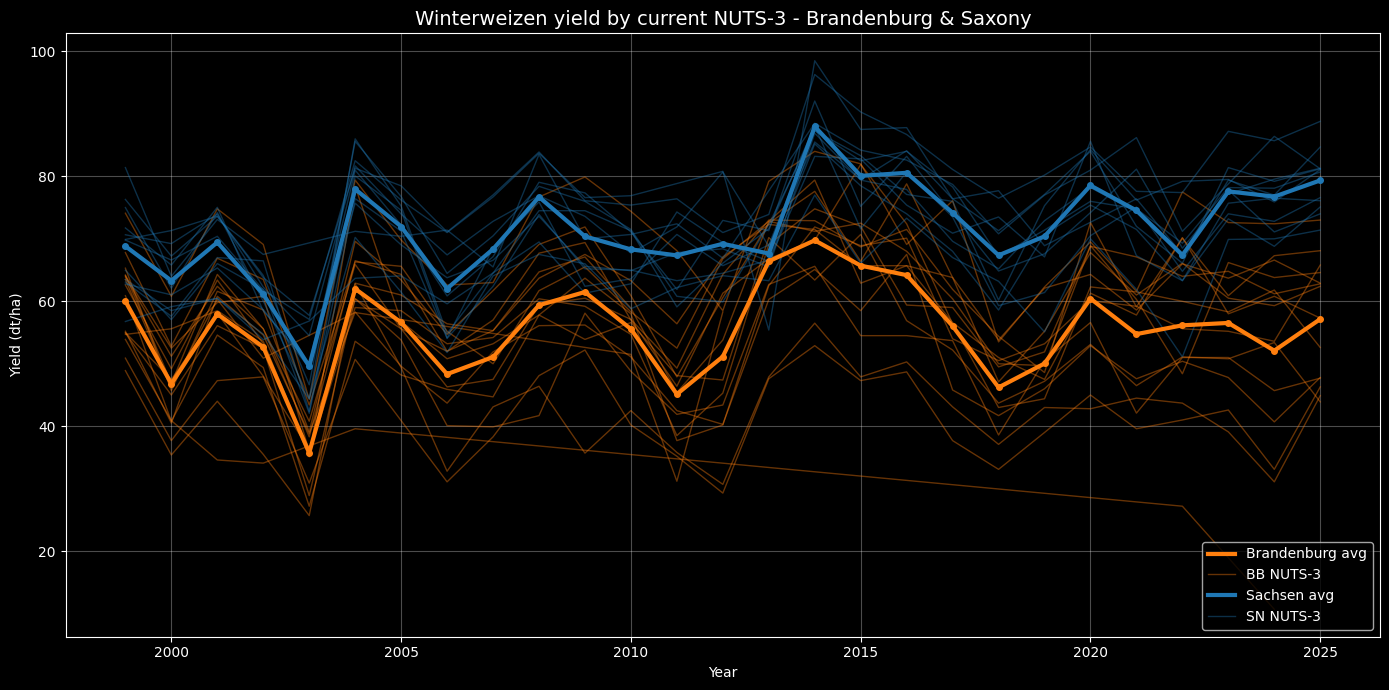

In [124]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(14, 7))

for nuts3_id, grp in bb_sn_ww_nuts3.groupby("nuts3_id"):
    grp = grp.sort_values("year")
    is_bb = nuts3_id.startswith("DE4")
    color = "tab:orange" if is_bb else "tab:blue"
    ax.plot(grp["year"], grp["yield_dt_ha"], color=color, alpha=0.4, linewidth=1)

for prefix, label, color in [
    ("DE4", "Brandenburg avg", "tab:orange"),
    ("DED", "Sachsen avg", "tab:blue"),
]:
    state_ww = bb_sn_ww_nuts3[bb_sn_ww_nuts3["nuts3_id"].str.startswith(prefix)]
    avg = state_ww.groupby("year")["yield_dt_ha"].mean().sort_index()
    ax.plot(avg.index, avg.values, color=color, linewidth=3, marker="o", markersize=4, label=label, zorder=5)

ax.set_title("Winterweizen yield by current NUTS-3 - Brandenburg & Saxony", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Yield (dt/ha)")
ax.grid(True, alpha=0.3)

legend_elements = [
    Line2D([0], [0], color="tab:orange", linewidth=3, label="Brandenburg avg"),
    Line2D([0], [0], color="tab:orange", linewidth=1, alpha=0.4, label="BB NUTS-3"),
    Line2D([0], [0], color="tab:blue", linewidth=3, label="Sachsen avg"),
    Line2D([0], [0], color="tab:blue", linewidth=1, alpha=0.4, label="SN NUTS-3"),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

## 5. Ingest decision & data source registry

Our nominal decision criterion was:

> If we get >=10 years of yield data for >=80% of BB/SN Landkreise => **ingest**.

Criterion|Assessment
---------|----------
**Spatial granularity** | Kreise (NUTS-3 bridge) from Regionalstatistik + Bundesland (NUTS-1) from Genesis
**Temporal coverage** | 1999-2025, annual
**Crop coverage** | 10 selected crops incl. Winterweizen, Roggen, Wintergerste, Sommergerste, Kartoffeln, Zuckerrueben, Winterraps, Silomais
**Germany coverage** | 346/401 current NUTS-3 matched with deterministic exact-normalized logic + finite overrides
**BB/SN present** | 29/31 current NUTS-3 (17/18 Brandenburg, 12/13 Sachsen)
**Kreis-level crop area** | Not present in `41241-01-03-4`; historic many-to-one bridges can therefore only be aggregated unweighted
**API reliability** | Official Destatis Genesis REST API, POST-only
**Licence** | Datenlizenz Deutschland - Namensnennung - Version 2.0

Therefore, the **decision** is to **INGEST** for evaluation and regional analysis:
Kreise yields as the primary fine-grained signal, Bundesland yields as the reference layer,
with an explicit caveat that pre-reform many-to-one bridges remain unweighted until Kreis-level
hectare data is sourced from another table family.


### Register in data_source_registry


#### Bundesland-level (Genesis)

Registering genesis_41241_bundesland with relative state coverage of:

In [125]:
bl_pct = round(
    con.sql("select count(distinct bundesland_code) * 100.0 / 16.0 from yields_bundesland").fetchone()[0],
    1,
)

bl_pct

81.2

In [ ]:
existing_bl = con.sql("select count(*) from data_source_registry where source_name = 'genesis_41241_bundesland'").fetchone()[0]

if existing_bl == 0:
    con.sql(f"""
        insert into data_source_registry (
            source_name, url, spatial_level, temporal_range, variables,
            auth_required, decision, reason, coverage_pct
        ) values (
            'genesis_41241_bundesland',
            'https://www-genesis.destatis.de/genesisWS/rest/2020',
            'Bundesland (NUTS-1)',
            '2010-2025 (annual)',
            'Yield (dt/ha), area (ha), harvest (t) - 31 crop types',
            true,
            'ingest',
            'Reference layer: Bundesland yields for 13/16 states, including area and harvest, used to sanity-check the Kreis-level series.',
            {bl_pct}
        )
    """)

#### Kreise-level (Regionalstatistik)

Registering regio_41241_kreise, with relative NUTS-3 coverage of:

In [127]:
total_de_nuts3 = con.sql("select count(*) from nuts3 where cntr_code = 'DE'").fetchone()[0]
matched_kreise_nuts3 = con.sql("select count(distinct nuts3_id) from yields_kreise").fetchone()[0]
kreise_pct = round(matched_kreise_nuts3 / total_de_nuts3 * 100, 1)
kreise_pct

86.3

In [ ]:
# Guard for existing if rerunning this notebook
existing_kr = con.sql("select count(*) from data_source_registry where source_name = 'regio_41241_kreise'").fetchone()[0]

if existing_kr == 0:
    con.sql(f"""
        insert into data_source_registry (
            source_name, url, spatial_level, temporal_range, variables,
            auth_required, decision, reason, coverage_pct
        ) values (
            'regio_41241_kreise',
            'https://www.regionalstatistik.de/genesisws/rest/2020',
            'Kreise (NUTS-3 bridge)',
            '1999-2025 (annual)',
            'Yield (dt/ha) - 10 selected crops; no Kreis-level area in the current table',
            true,
            'ingest',
            ('Primary Kreis-level yield source for evaluation: deterministic 346/401 current NUTS-3 matched overall and '
             '29/31 in Brandenburg+Sachsen. Historic many-to-one bridges remain unweighted because hectares '
             'are unavailable in this table.'),
            {kreise_pct}
        )
        """)

#### Confirm


In [ ]:
registry = con.sql("select source_name, spatial_level, decision, coverage_pct from data_source_registry order by source_name").df()
registry

,source_name,spatial_level,decision,coverage_pct
0,dwd_kl_stations,point -> NUTS-3 via ST_Contains,ingest,75.561096
1,genesis_41241_bundesland,Bundesland (NUTS-1),ingest,81.199997
2,regio_41241_kreise,Kreise (NUTS-3 bridge),ingest,86.300003


## Release DuckDB

Close DuckDB

In [130]:
db_size = DB_PATH.stat().st_size / 1024
print(f"DuckDB size: {db_size:.0f} KB")
con.close()
print("Done: DuckDB connection closed.")

DuckDB size: 11788 KB
Done: DuckDB connection closed.
